# Profiling Early Defects upon Eomes KD

In [1]:
here::i_am("rna_atac/differential/v2/01_early_defects.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ArchR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
# Define custom functions
plot_region = function(input_gene, gene_height = 1.5, no_label = F, bw_width = 10, bw_height = 10, extend.upstream = 3e3, extend.downstream = 3e3 ){
    tmp1 = DEG_DAR[celltype %in% args$celltypes & gene %in% input_gene] %>% 
        .[order(-abs(ATAC_logFC))] %>% unique(by = 'peak')
    gene_region = ArchRProject@geneAnnotation$genes[grep(paste0('^', input_gene, '$'), ArchRProject@geneAnnotation$genes$symbol)]
    peak_regions = as.numeric(str_split(str_split(tmp1$peak, ':') %>% map_chr(2), '-') %>% map_chr(1))
    start = min(c(start(ranges(gene_region)), peak_regions)) - extend.downstream
    end = max(c(c(end(ranges(gene_region)), peak_regions + 600))) + extend.upstream
    input_region = paste0(gene_region@seqnames@values, ':', start, '-', end)

    mypal <- colorRampPalette(c("#fff7b8","grey98","#d0ffc2"))(100)
    x <- tmp1[, ATAC_logFC]
    highlight_colors = map2color(x,mypal, limits = c(-max(abs(c(0,x))), max(abs(c(0,x)))))
    names(highlight_colors) = str_split(str_split(tmp1[, peak], ':') %>% map_chr(2), '-') %>% map_chr(1)

    plot_browser_track(gene = input_gene, # gene used for plotting expression
                                  input_region = input_region, # Region used
                                  bigwigs = WT_plot, 
                                  extend.upstream = 0,
                                  extend.downstream = 0, 
                                  highlight_regions = if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                                  downsample.rate = 1, 
                                  no_label = no_label, 
                                  plot_expression = T,
                                  background_color = 'white',
                                  highlight_color = if(length(highlight_colors)>0){highlight_colors}else{NULL},
                                  bw_height = bw_height, 
                                  gene_height = gene_height,
                                  bw_width = bw_width)
}

plot_enr_heatmap = function(motif_enrichment, ntop=25, TFs = NULL, title = 'Motifs in marker peaks', subtitle = NULL, color = 'darkblue') {

    if(!is.null(TFs)){
        keep_tfs = TFs
    }else{
        keep_tfs = motif_enrichment %>% .[,variable:=factor(celltype, levels= names(opts$celltype_v2.colors))] %>% .[order(c(celltype, -mlog10Padj))] %>% .[, head(.SD, ntop),  by=celltype] %>% .$feature   
    }
    
    enriched.dt = motif_enrichment[feature %in% keep_tfs] %>% .[order( -mlog10Padj)] %>% 
        #.[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
         .[,feature:=factor(feature, levels=unique(keep_tfs))] %>%
        .[,variable:=factor(celltype, levels=names(opts$celltype_v2.colors))]
    
    p = ggplot(enriched.dt, aes(feature, celltype, color = Enrichment, size=mlog10Padj)) + 
        geom_point() +
        scale_color_gradient2(low='white', mid = 'white', high=color, name='Enrichment', midpoint = 0) + # , breaks = c(0,100), labels = c('Min', 'Max')
        scale_y_discrete(expand = c(0, 0.5)) + 
        scale_x_discrete(expand = c(0, 0.5)) + 
        geom_hline(yintercept=seq(.5, 20, 1), alpha=0.2) + 
        geom_hline(yintercept=c(6.5, 7.5), alpha=1) + 
        guides(colour = guide_colourbar(
            # barwidth = 1, barheight = 1,
            frame.colour = "black", 
            ticks.colour = "black"
        )) + 
        labs(title = title, caption = subtitle) + 
        theme(text=element_text(size=12), 
             axis.text = element_text(color='black'),
             axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=12), 
             axis.text.y= element_text(hjust=1, size = 12), # element_blank(), #
             axis.title = element_blank(),
             panel.border = element_rect(color='black', linewidth=1, fill = NA),
             panel.background = element_blank(),
             plot.title = element_text(size=14, face='plain', hjust=0.5),
             axis.line = element_blank(),
             legend.title = element_text(hjust=0, vjust = 0.85),
             legend.text = element_text(hjust=0.5, vjust = 0.5),
             legend.position = 'bottom')
    
p
    return(p)
}

In [3]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# Load Differential analysis
args$expression = file.path(io$basedir, 'results/rna_atac/differential/v2/expression/')
args$accessibility = file.path(io$basedir, 'results/rna_atac/differential/v2/Accessibility/')
args$WT_trajectory = file.path(io$basedir, 'results/rna_atac/trajectory/v3')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/differential/v2/01_early_defects/test')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

# Celltypes to use
args$celltypes = c('Primitive_Streak', 'Early_Mes_EOi')

In [4]:
# Load browser track files
ArchRProject = suppressMessages(ArchR::loadArchRProject(io$archR.directory))

args$vitro_bws = file.path(io$basedir, 'processed/atac/archR/GroupBigWigs/celltypeV2_genotype/')

bigwigs.data_vitro = data.table(celltype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(1),
                    genotype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(2) %>% str_split('-') %>% map_chr(1),
                    path =  paste0(args$vitro_bws, list.files(args$vitro_bws, 'bw'))) %>% 
                .[,name := paste0(str_replace_all(celltype, opts$celltype_v2_figure), ' ', gsub('KO', 'KD', genotype))] %>% 
                .[,color := ifelse(genotype == 'KO', '#FF0000', '#000000')] %>% 
                .[name != 'Blood_Progenitor-KO']

bigwig_order = c(
                'Primitive Streak WT','Primitive Streak KD',
                'Early-Mes #1 WT','Early-Mes #1 KD'
)
WT_plot = bigwigs.data_vitro %>% copy() %>%
    .[genotype %in% c('WT', 'KO')] %>% 
    .[match(bigwig_order, name)] %>% 
    .[, name := factor(name, levels = bigwig_order)]

In [5]:
# Load meta
meta = fread(args$metadata)[day!='D3']

#### Load Data

In [6]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [7]:
# Load differential RNA
DEGs = fread(sprintf('%s/DEGs_edgeR_pb.txt.gz', args$expression))[celltype %in% args$celltypes] %>% 
        .[,sig:=ifelse(abs(logFC)>0.5 & padj_fdr < 0.05, TRUE, FALSE)] %>% 
        .[sig == T] %>% .[, sig := NULL]
DEGs = DEGs[!gene %in% c('Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bh1')]

# Load differential ATAC
DARs = fread(sprintf('%s/DARs_edgeR_pb.txt.gz', args$accessibility))[celltype %in% args$celltypes] %>% 
        .[,sig:=ifelse(abs(logFC)>0.5 & padj_fdr < 0.05, TRUE, FALSE)] %>% 
        .[sig == T] %>% .[, sig := NULL]

# Load peak2gene linkage
peak_gene_correlation = fread(file.path(args$WT_trajectory, 'acc_gene_correlation.txt.gz')) %>% 
    # .[padj<0.05] %>% 
    .[]

# Get differential genes from trajectory analysis between the two lineages in WT
patternGenes = fread(file.path(args$WT_trajectory, 'patternGenes.txt.gz'))
endGenes = fread(file.path(args$WT_trajectory, 'endGenes.txt.gz'))
genes_keep = unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene)

## Use ArchR to identify differential peaks rather than EdgeR

In [51]:
meta = fread(paste0(io$basedir, '/results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')) %>% 
    .[day != 'D3']
ArchRProject = loadArchRProject(io$archR.directory)[meta$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [52]:
summary(rownames(ArchRProject@cellColData) == meta$cell)

   Mode    TRUE 
logical   27135 

In [53]:
meta = meta %>% 
    .[, celltype_genotype := paste0(celltype_v2, '_', genotype)]

In [55]:
ArchRProject = addCellColData(
  ArchRProj = ArchRProject,
  data = meta$celltype_genotype,
  name = 'celltype_genotype',
  cells = meta$cell,
  force = TRUE
)

Overriding previous entry for celltype_genotype



In [56]:
table(ArchRProject@cellColData$celltype_genotype)


          Allantois_KO Allantois_Precursor_KO Allantois_Precursor_WT 
                  1446                   1389                    399 
          Allantois_WT    Blood_Progenitor_KO    Blood_Progenitor_WT 
                   429                      1                    244 
      Early_Mes_EOd_KO       Early_Mes_EOd_WT       Early_Mes_EOi_KO 
                   258                   5472                   3513 
      Early_Mes_EOi_WT         Endothelium_KO         Endothelium_WT 
                  1706                    431                    206 
                 HE_KO        HE_Precursor_KO        HE_Precursor_WT 
                   374                    103                   1290 
                 HE_WT          Mesenchyme_KO          Mesenchyme_WT 
                  1734                    316                   1675 
                PGC_KO                 PGC_WT       Posterior_Mes_KO 
                   334                    350                   2864 
      Posterior_Mes

In [57]:
ArchR::addArchRThreads(24)

Setting default number of Parallel threads to 24.



In [58]:
getAvailableMatrices(ArchRProject)

[1] "DeviationMatrix_CISBP"   "DeviationMatrix_JASPAR" 
 [3] "GeneScoreMatrix_TSS"     "GeneScoreMatrix_distal" 
 [5] "MarkerPeaksMatrix"       "MotifMatrix"            
 [7] "PeakMatrix"              "PeakMatrix_atlas"       
 [9] "TileMatrix"              "silicoChIPMatrix"       
[11] "silicoChIP_CISBPMatrix"  "silicoChIP_CISBP_v2"    
[13] "silicoChIP_JASPARMatrix" "silicoChIP_JASPAR_v2"

In [59]:
# DARs_PS = getMarkerFeatures(
#   ArchRProj = ArchRProject,
#   groupBy = "celltype_genotype",
#   useGroups = 'Primitive_Streak_KO',
#   bgdGroups = 'Primitive_Streak_WT',
#   useMatrix = "PeakMatrix",
#   bias = c("TSSEnrichment", "log10(nFrags)"),
#   normBy = NULL,
#   testMethod = "wilcoxon",
#   maxCells = 500,
#   scaleTo = 10^4,
#   threads = getArchRThreads(),
#   k = 100,
#   bufferRatio = 0.8,
#   binarize = FALSE,
#   useSeqnames = NULL,
#   verbose = TRUE,
#   logFile = createLogFile("getMarkerFeatures")
# )

In [222]:
# This tests for all peaks, so could manually filter out the ones that are not of interest due to 
# low accessibility and recalculate FDR on only the remaining peaks
DARs_PS = getMarkerFeatures(
  ArchRProj = ArchRProject,
  groupBy = "celltype_genotype",
  useGroups = 'Primitive_Streak_KO',
  bgdGroups = 'Primitive_Streak_WT',
  useMatrix = "PeakMatrix",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  normBy = NULL, #"ReadsInTSS",
  testMethod = "binomial",
  maxCells = 10000,
  scaleTo = 10^4,
  threads = getArchRThreads(),
  k = 100,
  bufferRatio = 1,
  binarize = TRUE,
  useSeqnames = NULL,
  verbose = FALSE,
  logFile = createLogFile("getMarkerFeatures")
)

# This tests for all peaks, so could manually filter out the ones that are not of interest due to 
# low accessibility and recalculate FDR on only the remaining peaks
DARs_EM = getMarkerFeatures(
  ArchRProj = ArchRProject,
  groupBy = "celltype_genotype",
  useGroups = 'Early_Mes_EOi_KO',
  bgdGroups = 'Early_Mes_EOi_WT',
  useMatrix = "PeakMatrix",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  normBy = NULL, #"ReadsInTSS",
  testMethod = "binomial",
  maxCells = 10000,
  scaleTo = 10^4,
  threads = getArchRThreads(),
  k = 100,
  bufferRatio = 1,
  binarize = TRUE,
  useSeqnames = NULL,
  verbose = FALSE,
  logFile = createLogFile("getMarkerFeatures")
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-10a4ed4befba09-Date-2024-09-24_Time-12-48-00.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

Pairwise Test Primitive_Streak_KO : Seqnames chr1

Pairwise Test Primitive_Streak_KO : Seqnames chr10

Pairwise Test Primitive_Streak_KO : Seqnames chr11

Pairwise Test Primitive_Streak_KO : Seqnames chr12

Pairwise Test Primitive_Streak_KO : Seqnames chr13

Pairwise Test Primitive_Streak_KO : Seqnames chr14

Pairwise Test Primitive_Streak_KO : Seqnames chr15

Pairwise Test Primitive_Streak_KO : Seqnames chr16

Pairwise Test Primitive_Streak_KO : Seqnames chr17

Pairwise Test Primitive_Streak_KO : Seqnames chr18

Pairwise Test Primitive_Streak_KO : Seqnames chr19

Pairwise Test Primitive_Streak_KO : Seqnames chr2

Pairwise Test Primitive_Streak_KO : Seqnames chr3

Pairwise Test Primitive_Streak_KO : Seqnames chr4

Pairwise Test Primitive_Streak_KO : Seqnames chr5

Pairwise Test Primitive_S

In [223]:
DARs_PS.dt = data.table(peak = paste0(rowData(DARs_PS)$seqnames, ':', rowData(DARs_PS)$start, '-', rowData(DARs_PS)$end),
                        log2FC = DARs_PS@assays@data$MeanDiff$x,
                        FDR = DARs_PS@assays@data$FDR$x,
                        celltype = 'Primitive_Streak'
                       )

DARs_EM.dt = data.table(peak = paste0(rowData(DARs_EM)$seqnames, ':', rowData(DARs_EM)$start, '-', rowData(DARs_EM)$end),
                        log2FC = DARs_EM@assays@data$MeanDiff$x,
                        FDR = DARs_EM@assays@data$FDR$x,
                        celltype = 'Early_Mes#1'
                       )

DARs = rbind(DARs_PS.dt, DARs_EM.dt)
head(DARs_PS.dt)

peak,log2FC,FDR,celltype
<chr>,<dbl>,<dbl>,<chr>
chr1:3003470-3004070,0.001481481,0.9718551,Primitive_Streak
chr1:3035598-3036198,0.000000000,1.0000000,Primitive_Streak
chr1:3062639-3063239,-0.010370370,0.4313423,Primitive_Streak
chr1:3191587-3192187,0.004444444,0.9296227,Primitive_Streak
chr1:3263590-3264190,0.011851852,0.4952156,Primitive_Streak
chr1:3482948-3483548,0.005925926,0.8333413,Primitive_Streak


Warning message:
“Removed 13 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”


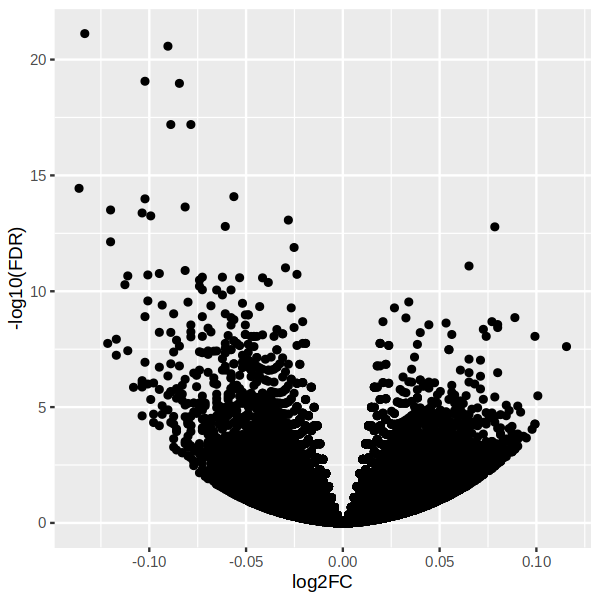

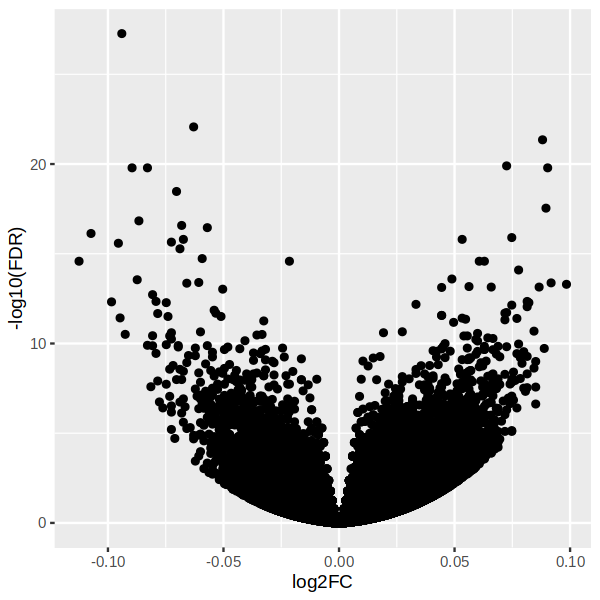

In [224]:
options(repr.plot.height= 5, repr.plot.width=5)
ggplot(DARs_PS.dt, aes(log2FC, -log10(FDR))) + geom_point()
ggplot(DARs_EM.dt, aes(log2FC, -log10(FDR))) + geom_point()

In [225]:
# link DEGs & DARs
DEG_DAR = DEGs %>% copy() %>%  
                    .[!is.na(logFC)] %>% 
                   setnames(colnames(.)[2:7], paste0('RNA_', colnames(.)[2:7])) %>% 
          merge(., peak_gene_correlation[,c('peak', 'gene', 'cor', 'padj')], 
                by = 'gene', allow.cartesian=TRUE) %>% 
          merge(., DARs %>% copy() %>%  
                    .[!is.na(log2FC)] %>% 
                    .[abs(log2FC) >= 0.05 & FDR < 0.1] %>% 
                    setnames('log2FC', 'logFC') %>% .[, celltype := NULL] %>%
                   setnames(colnames(.)[2:3], paste0('ATAC_', colnames(.)[2:3])),
                by = c('peak'), allow.cartesian=TRUE) %>% 
    unique(by = c('peak', 'gene'))

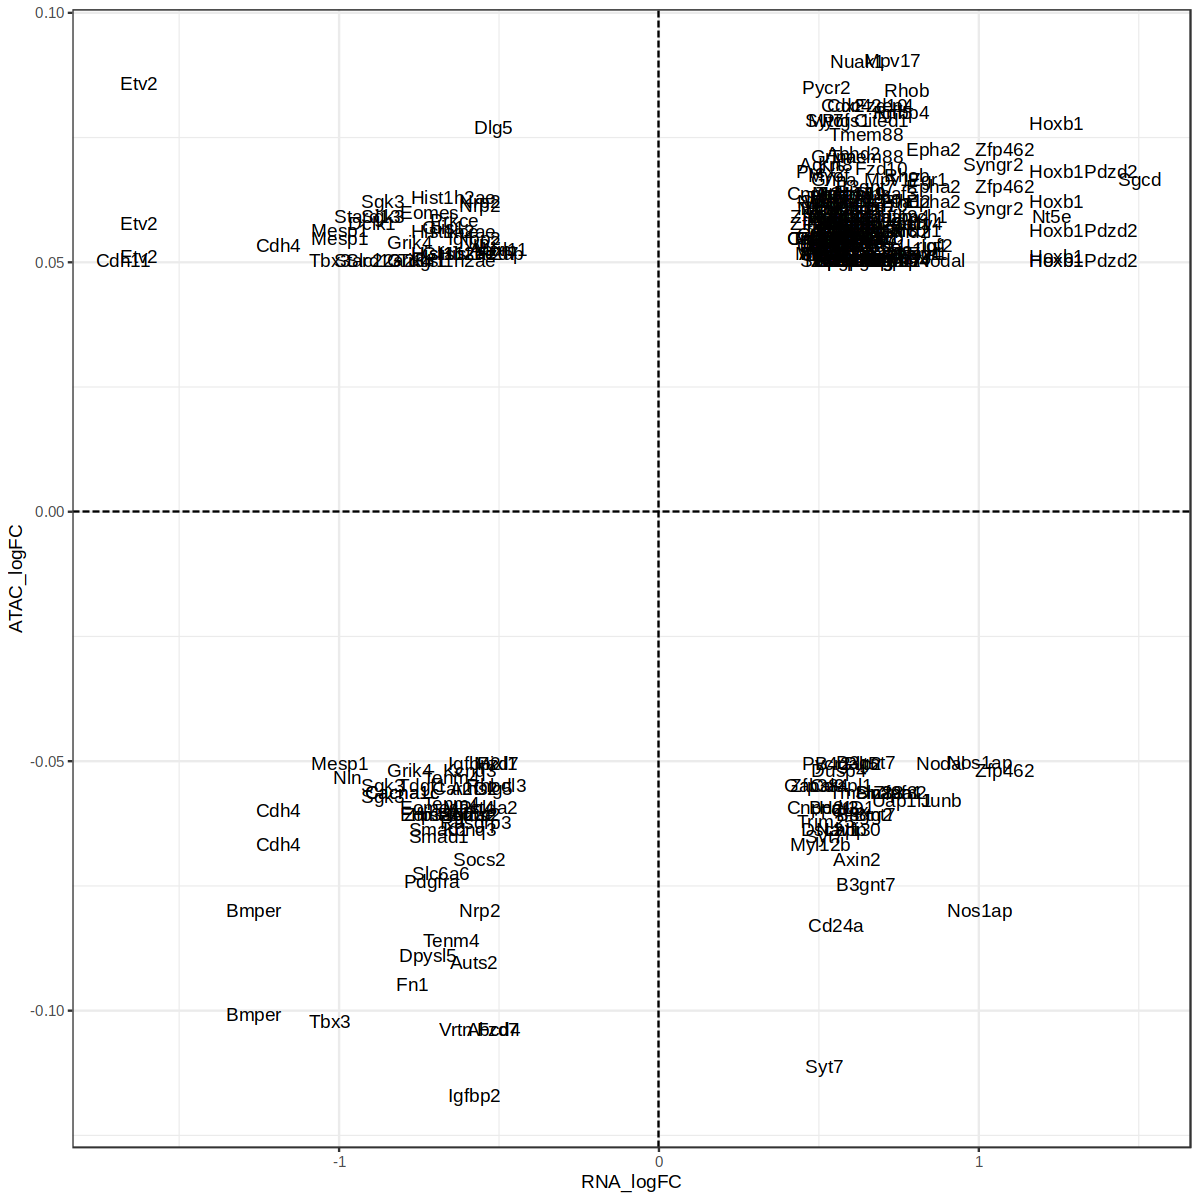

In [237]:
options(repr.plot.height= 10, repr.plot.width=10)
ggplot(DEG_DAR, aes(RNA_logFC, ATAC_logFC)) + 
    geom_text(aes(label = gene)) + 
    geom_hline(yintercept = 0, linetype = 'longdash') + 
    geom_vline(xintercept = 0, linetype = 'longdash') + 
    theme_bw()

In [227]:
rna.sce$genotype = gsub('KO', 'KD', rna.sce$genotype)

In [247]:
rna.sce$genotype = gsub('KD', 'KO', rna.sce$genotype)

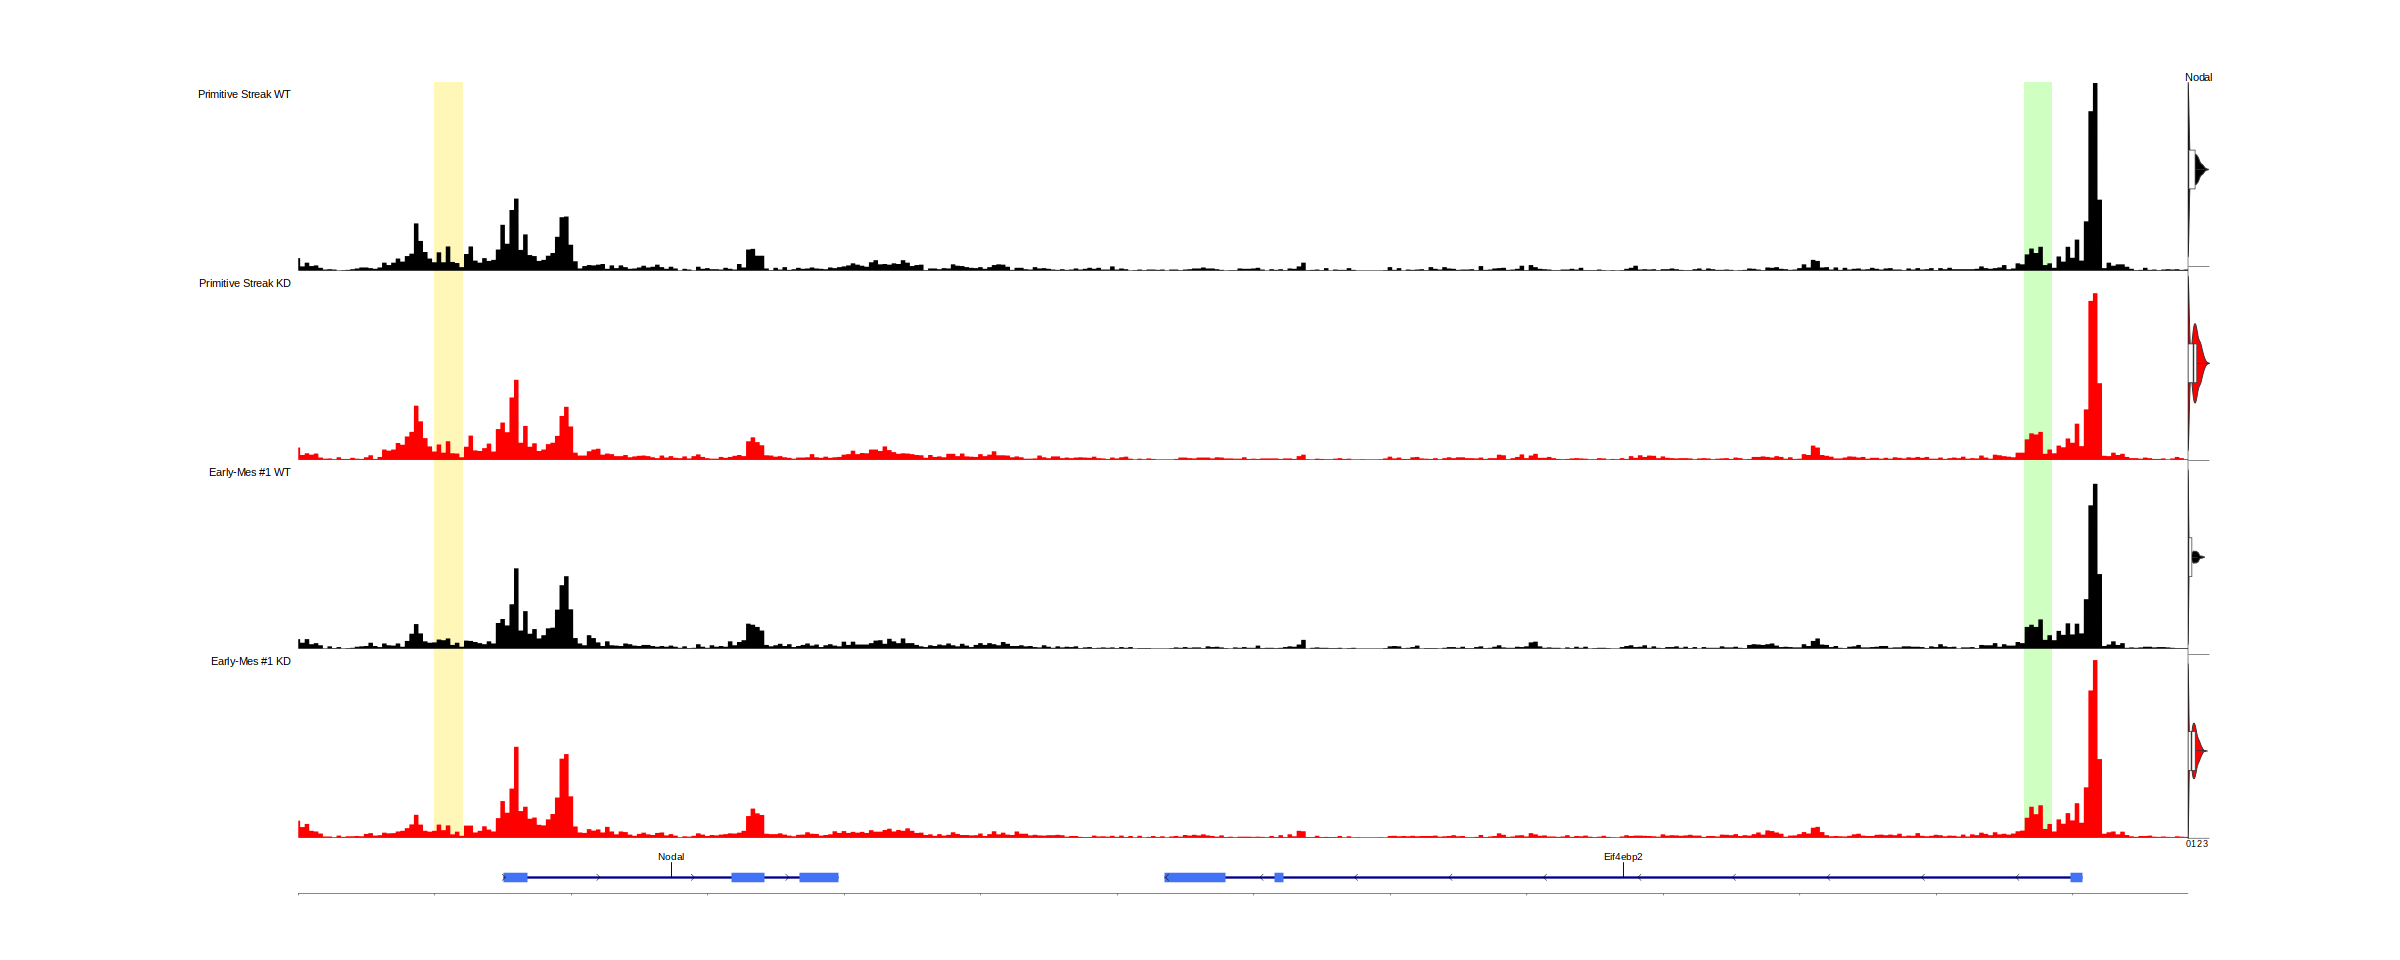

In [254]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Nodal', gene_height = 10, bw_width = 400, bw_height = 40)

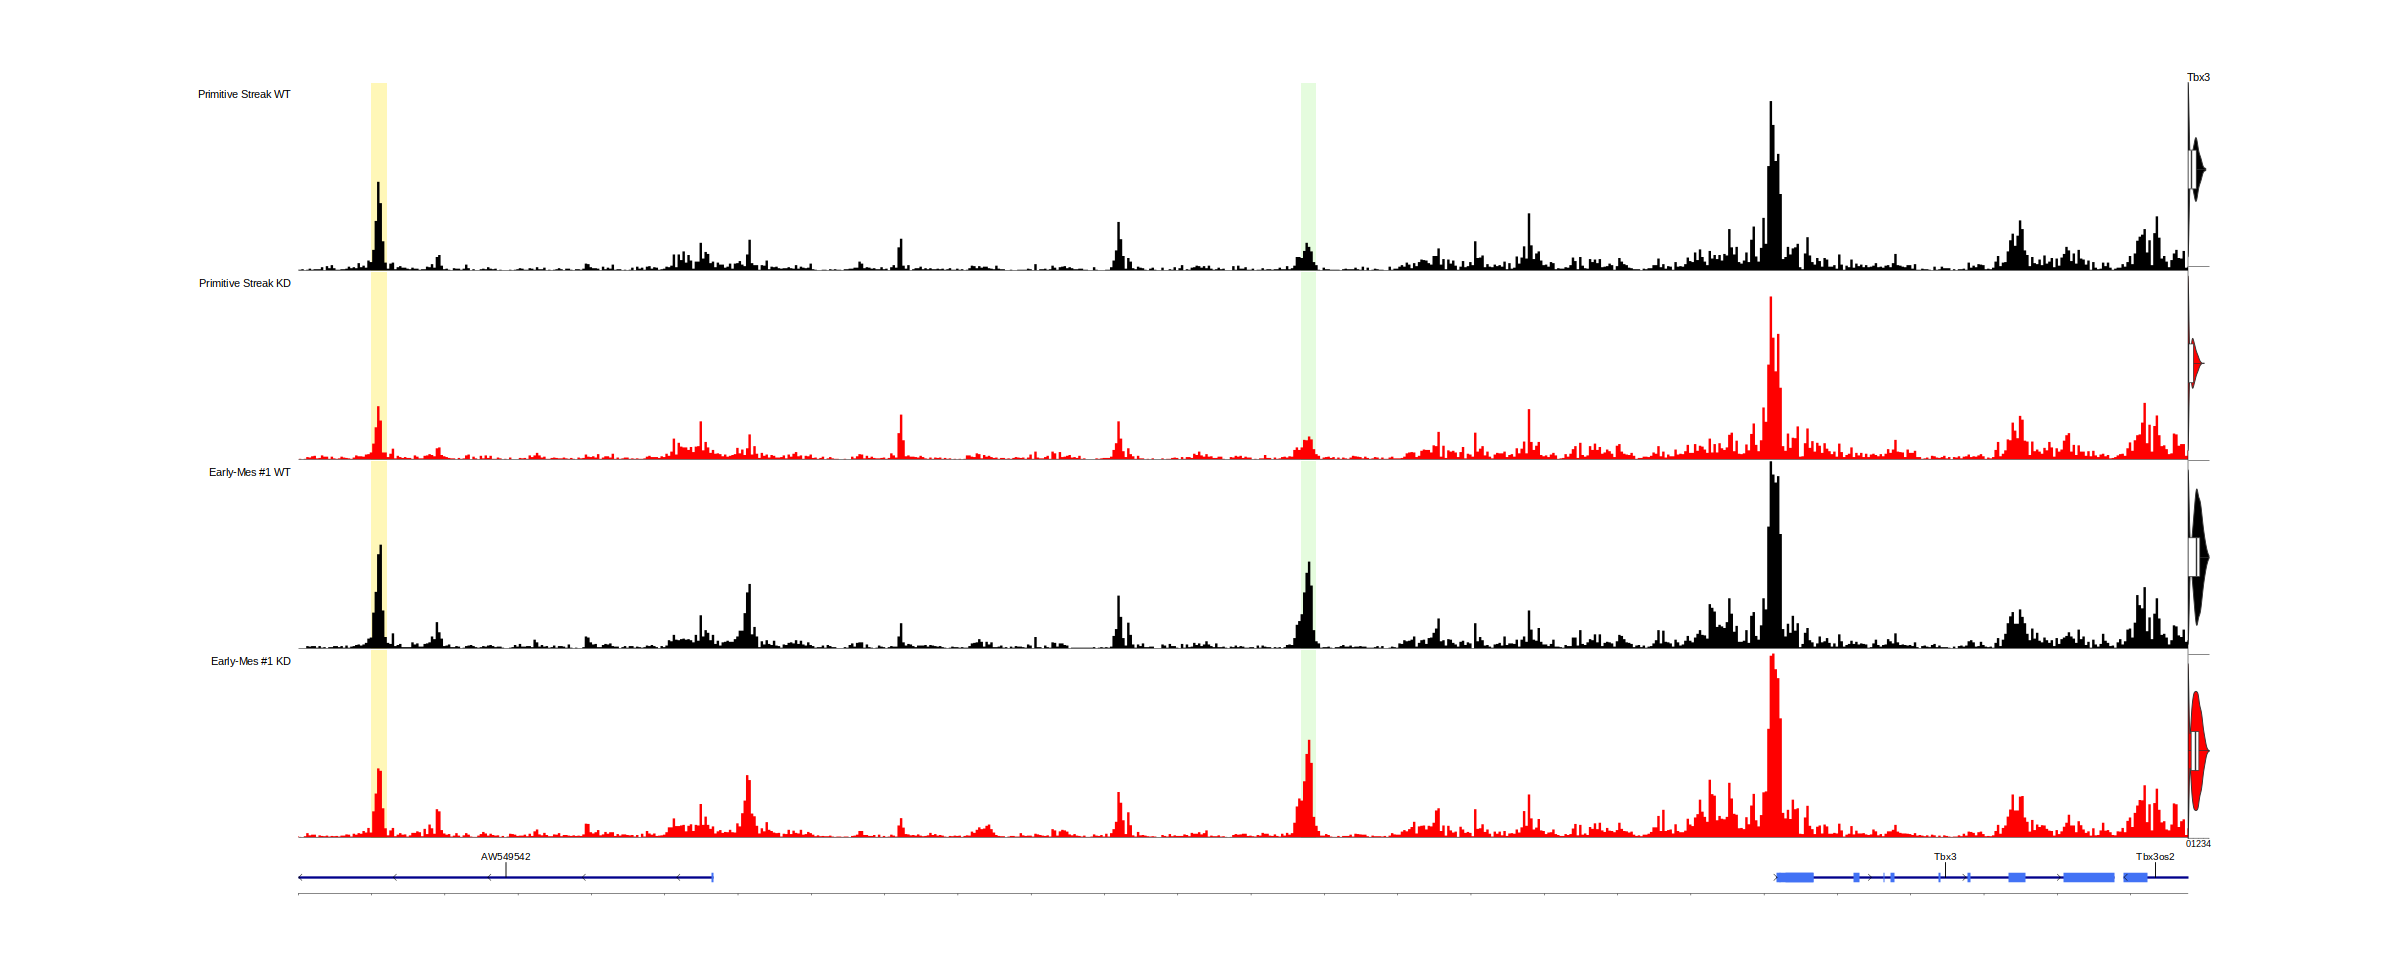

In [248]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Tbx3', gene_height = 10, bw_width = 400, bw_height = 40)

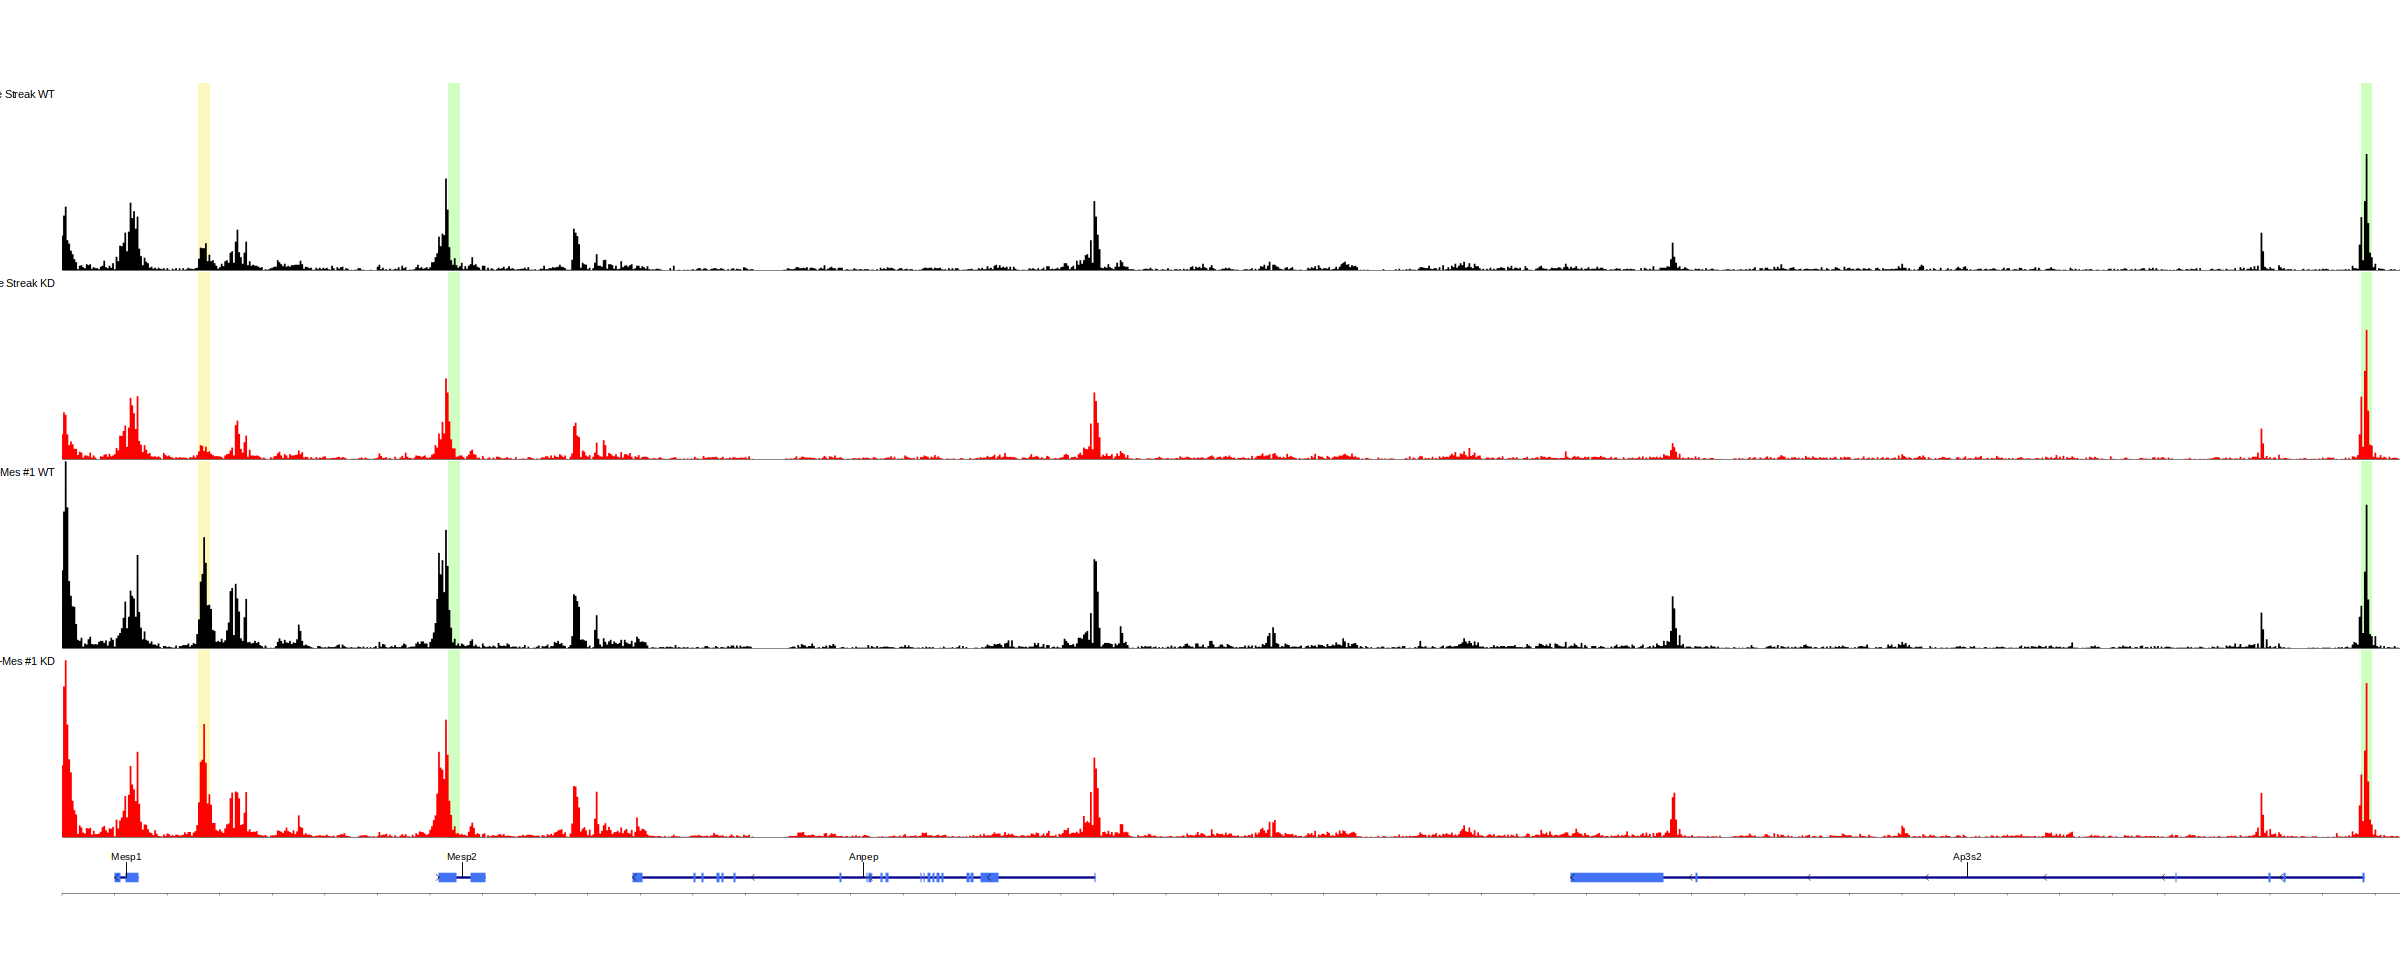

In [229]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Mesp1', gene_height = 10, bw_width = 500, bw_height = 40)


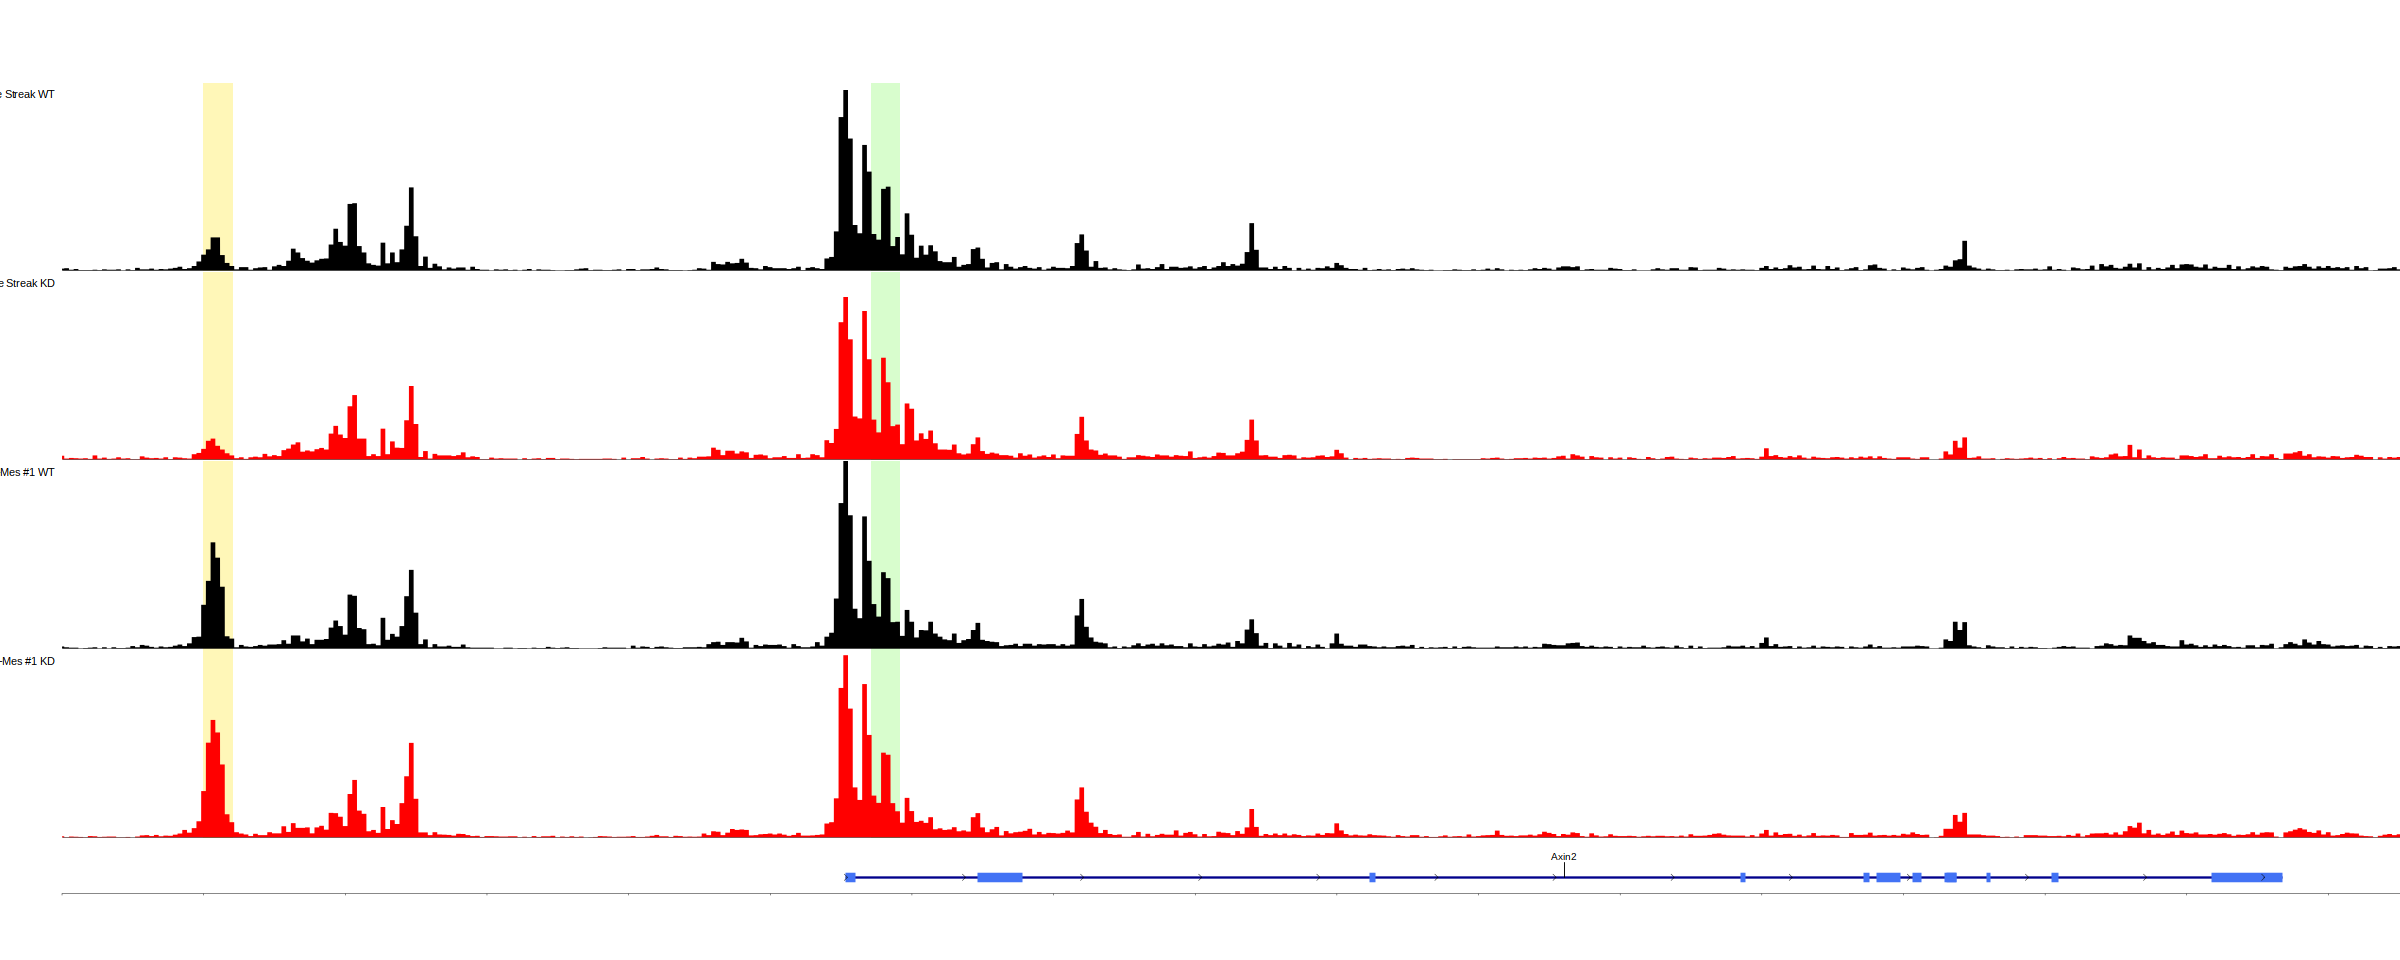

In [230]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Axin2', gene_height = 10, bw_width = 500, bw_height = 40)


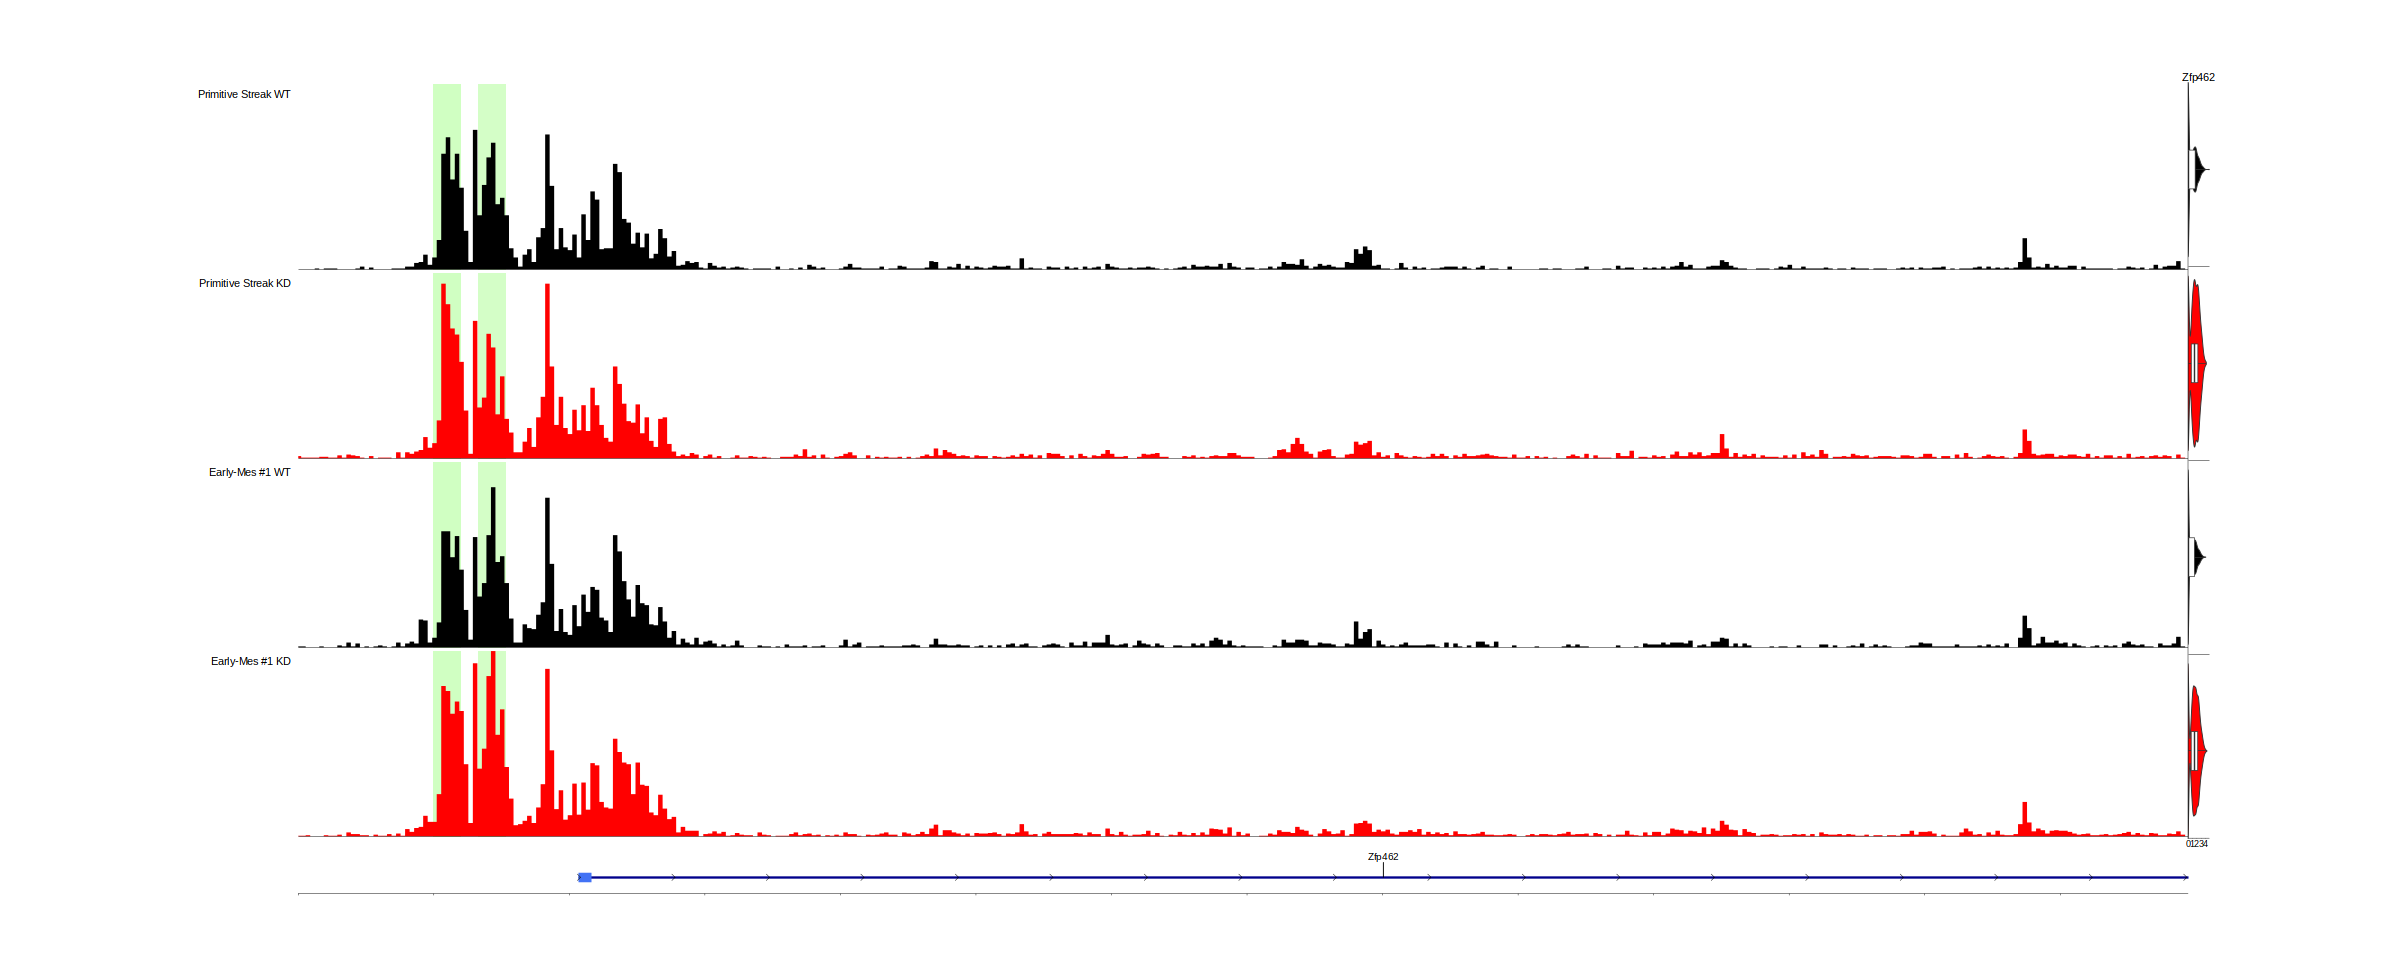

In [252]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Zfp462', gene_height = 10, bw_width = 400, bw_height = 40, extend.upstream = -1e5)


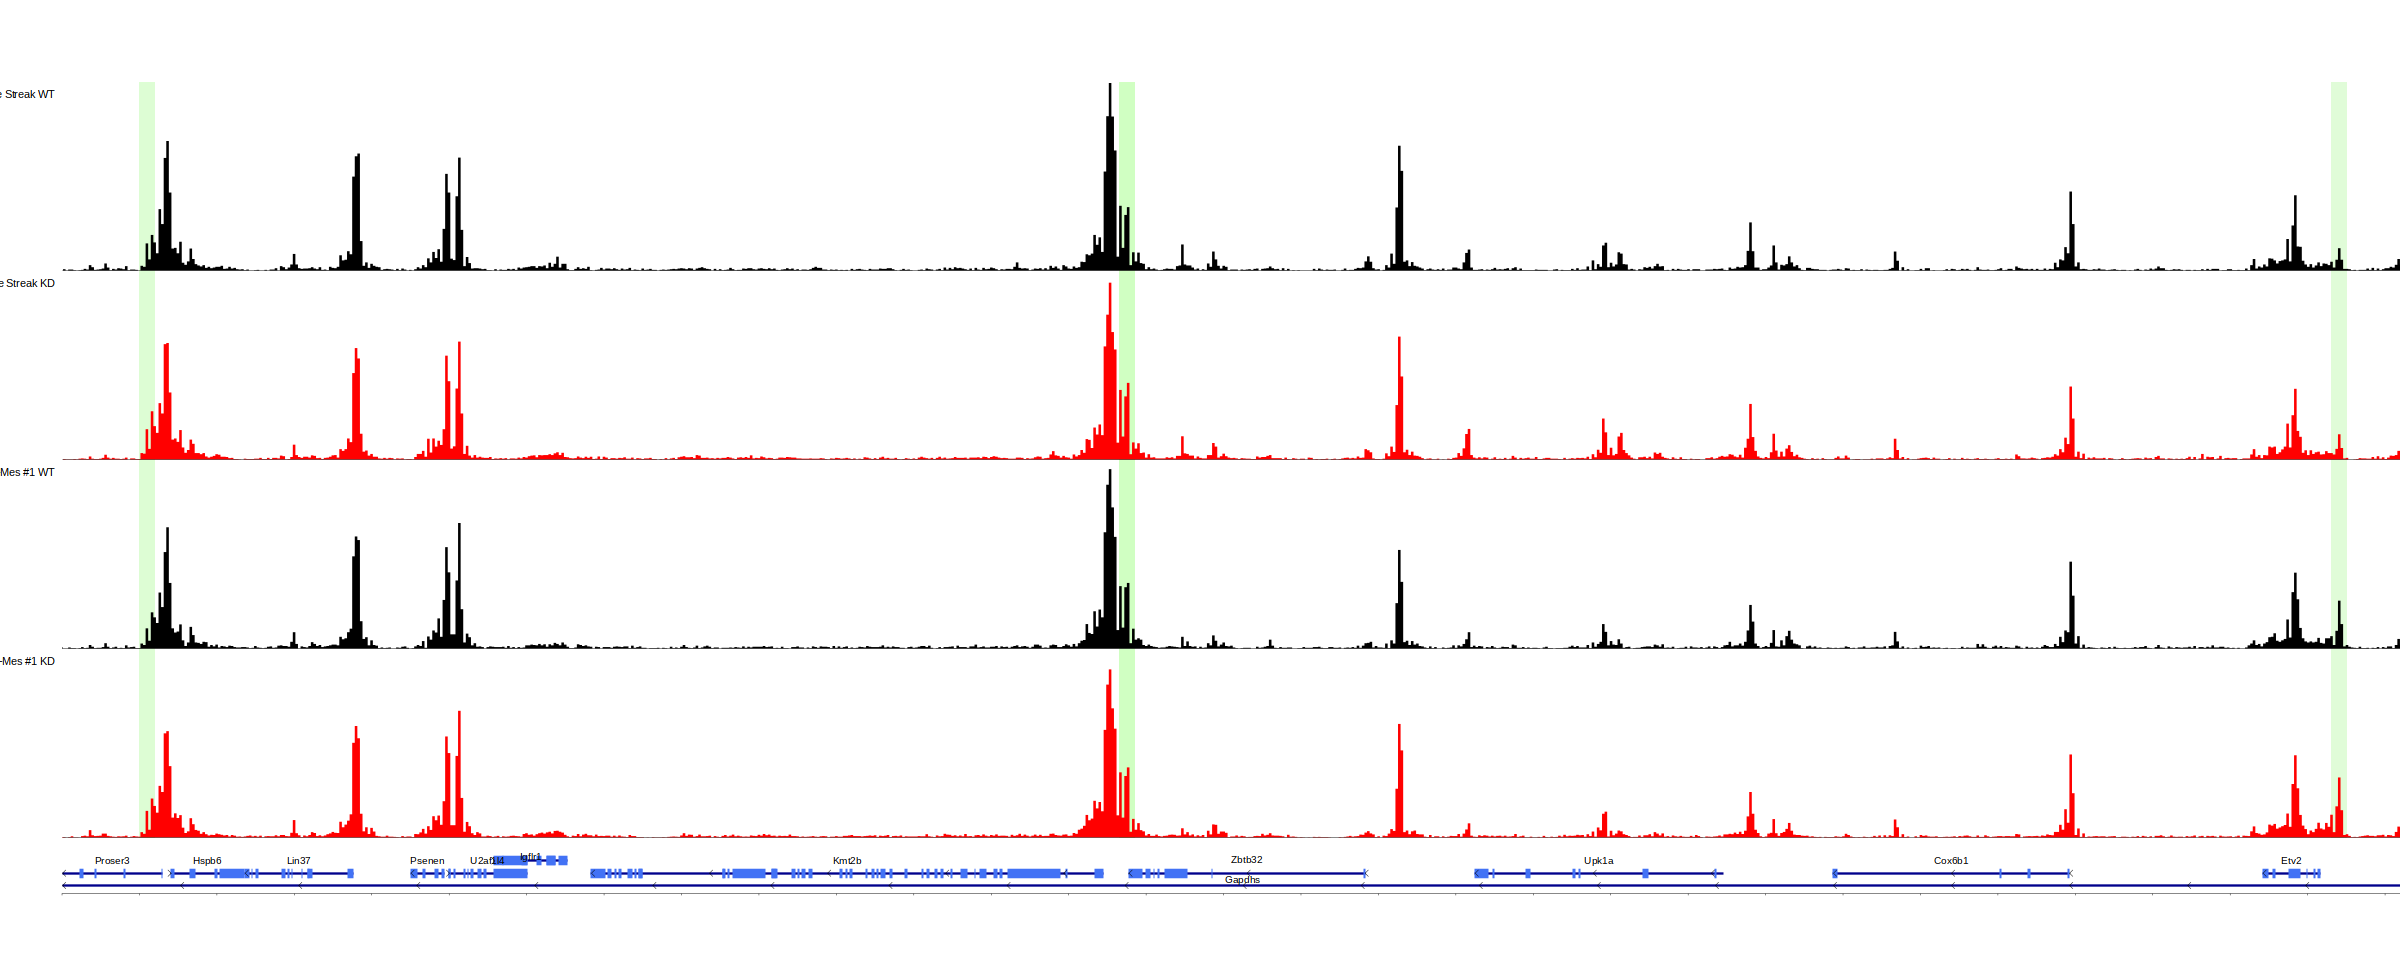

In [232]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Etv2', gene_height = 10, bw_width = 500, bw_height = 40)


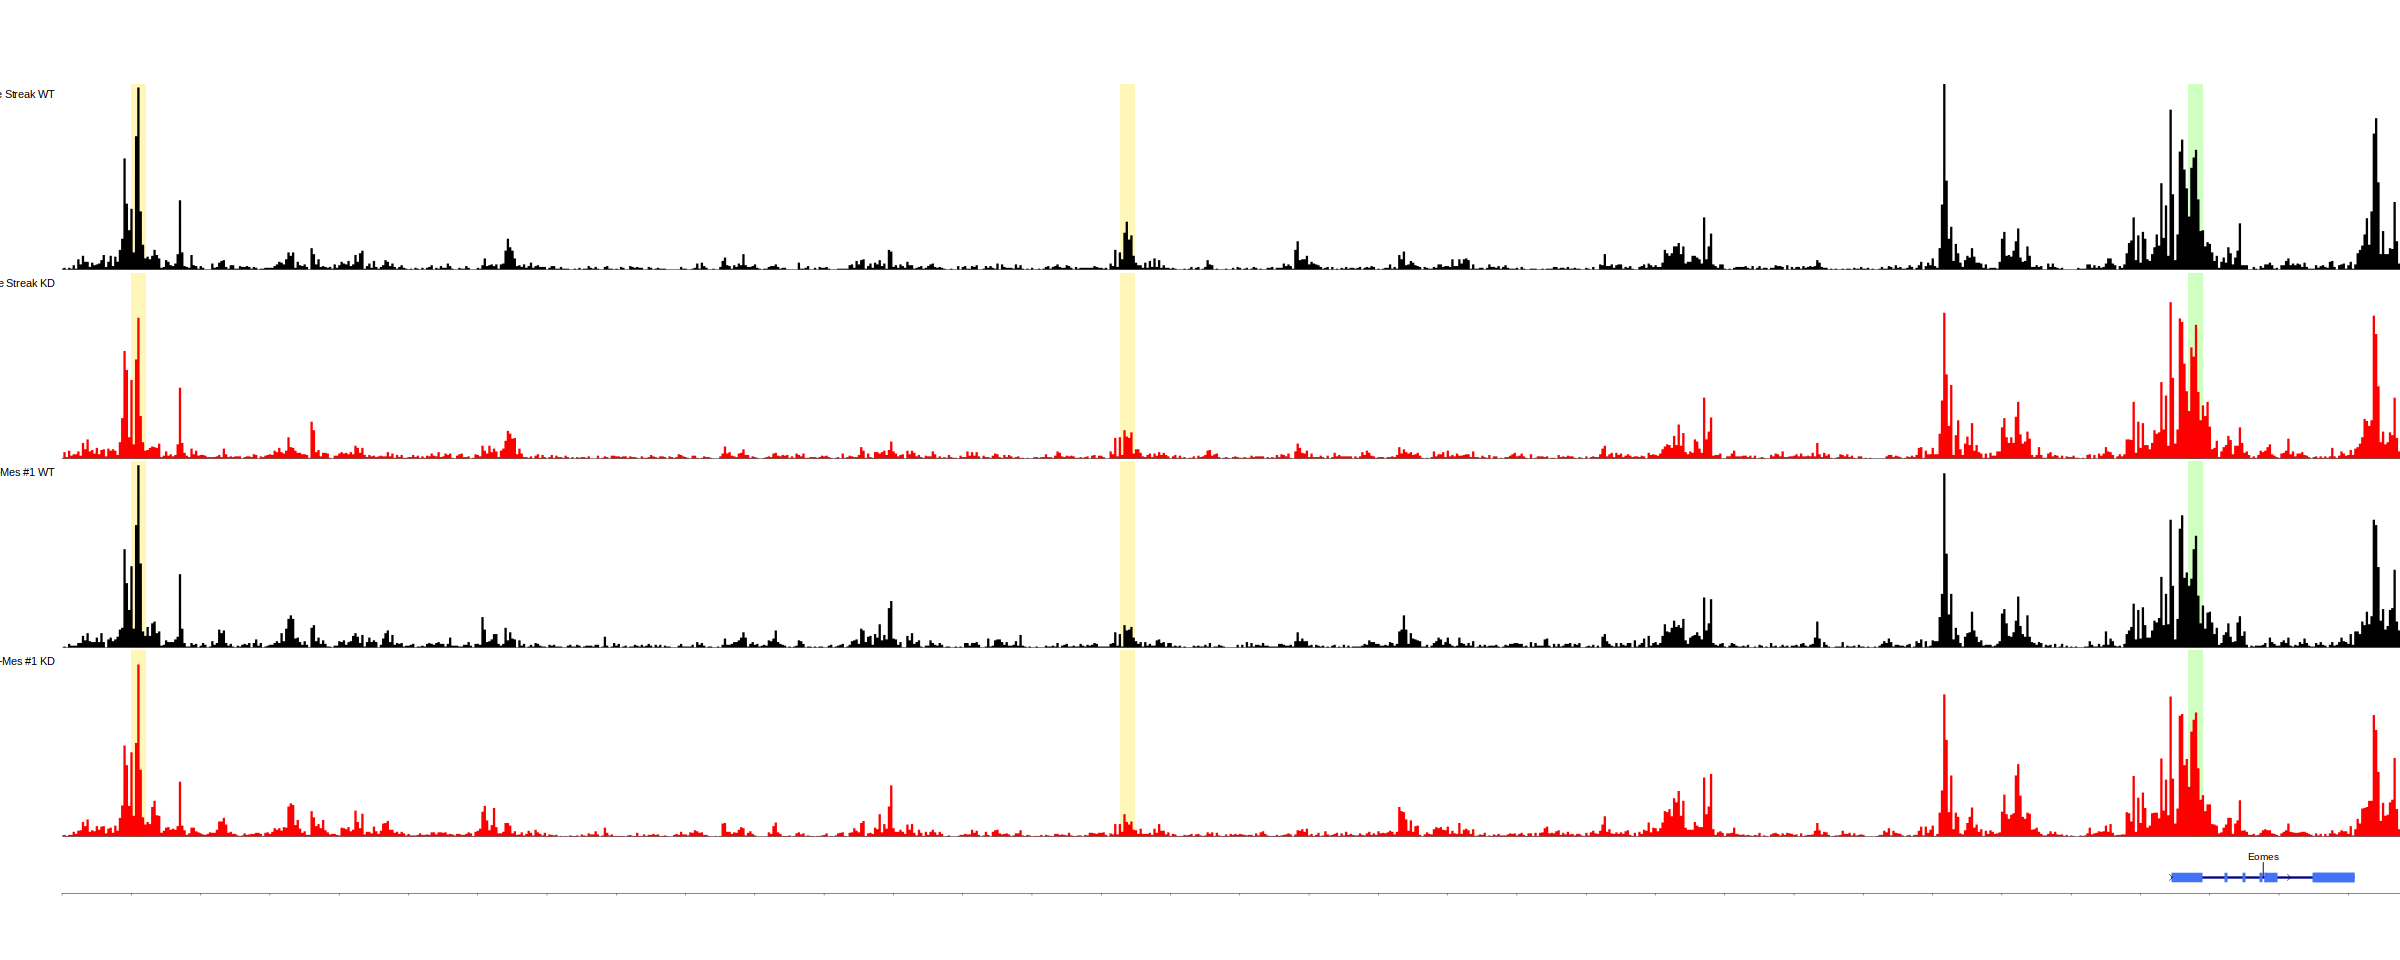

In [233]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Eomes', gene_height = 10, bw_width = 500, bw_height = 40)


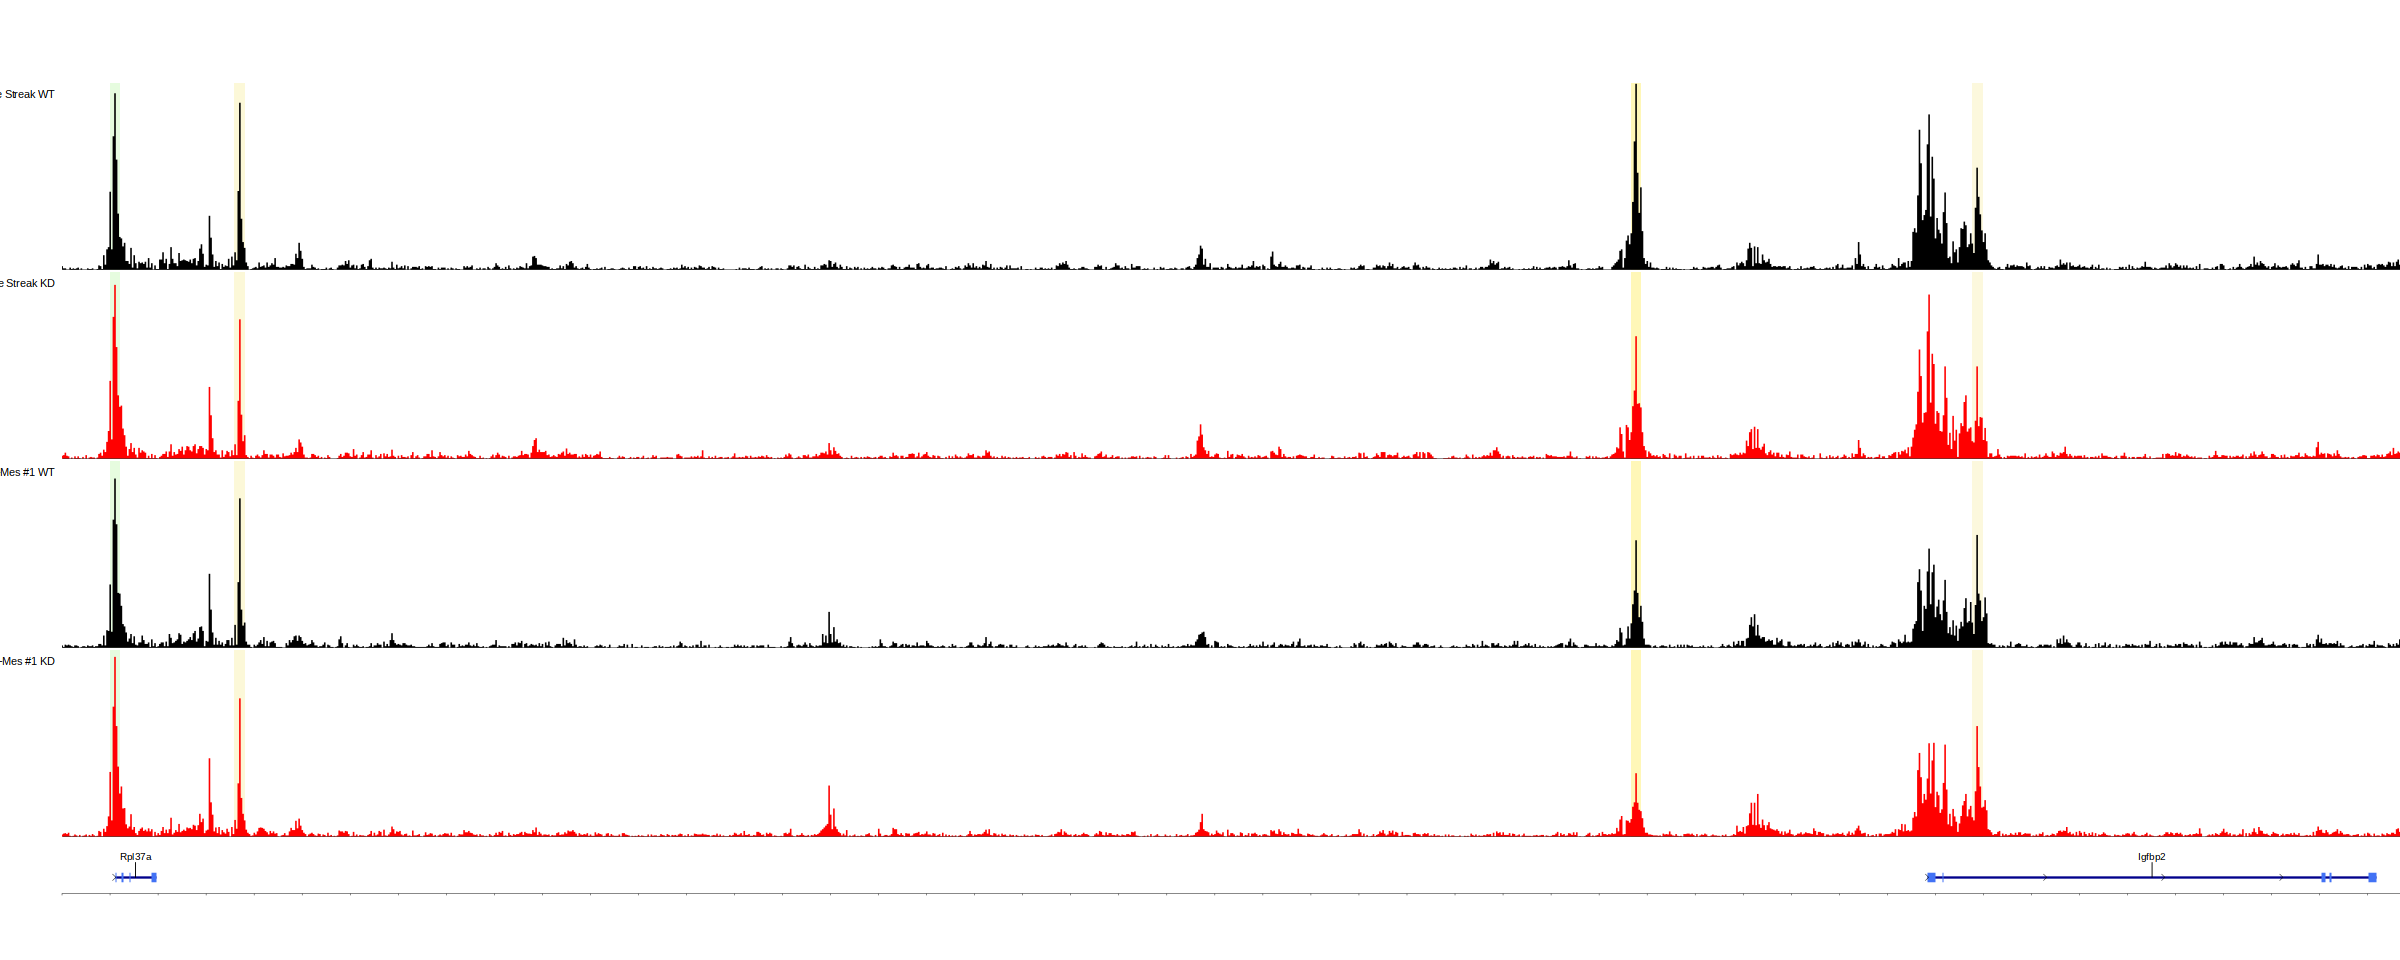

In [234]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Igfbp2', gene_height = 10, bw_width = 500, bw_height = 40)


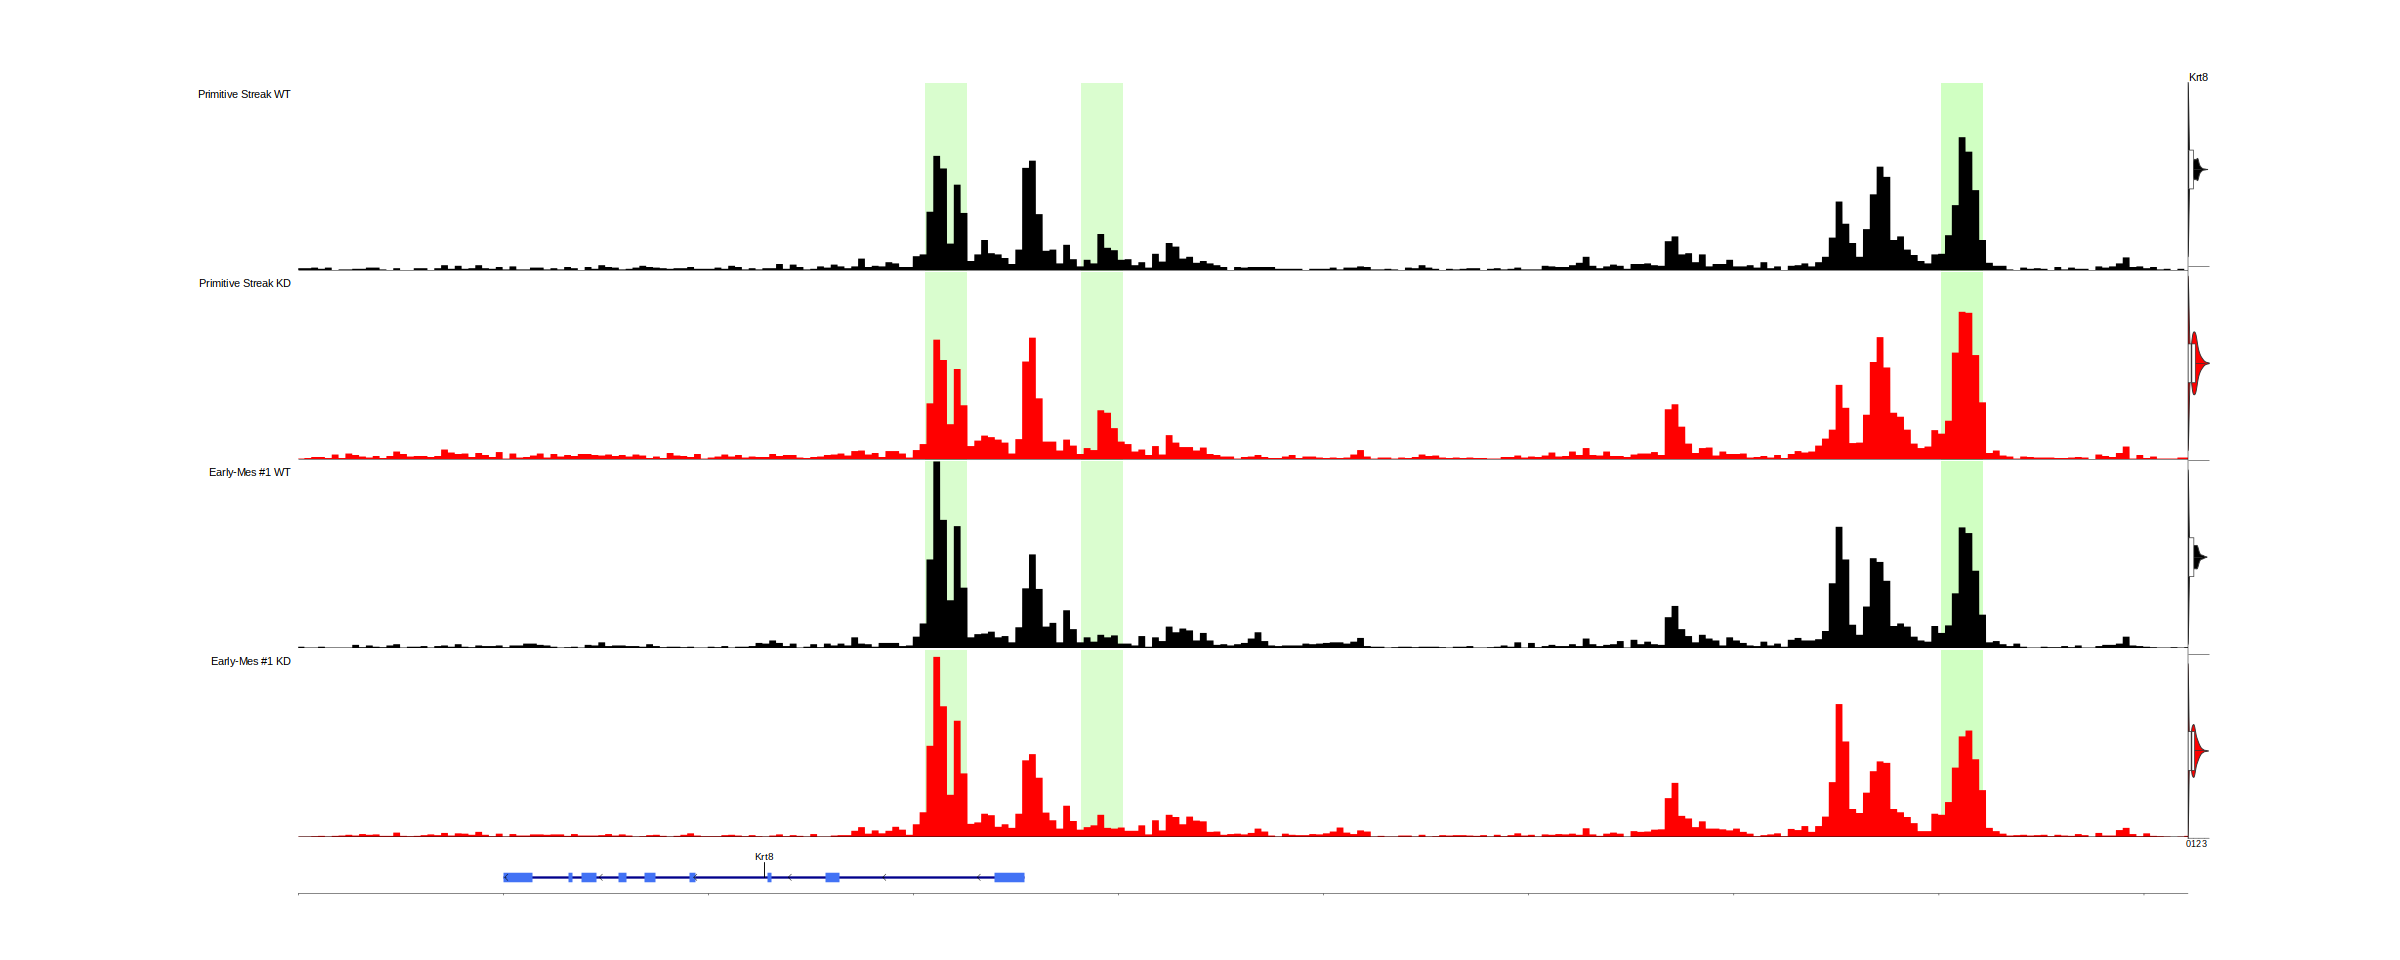

In [253]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Krt8', gene_height = 10, bw_width = 400, bw_height = 40)


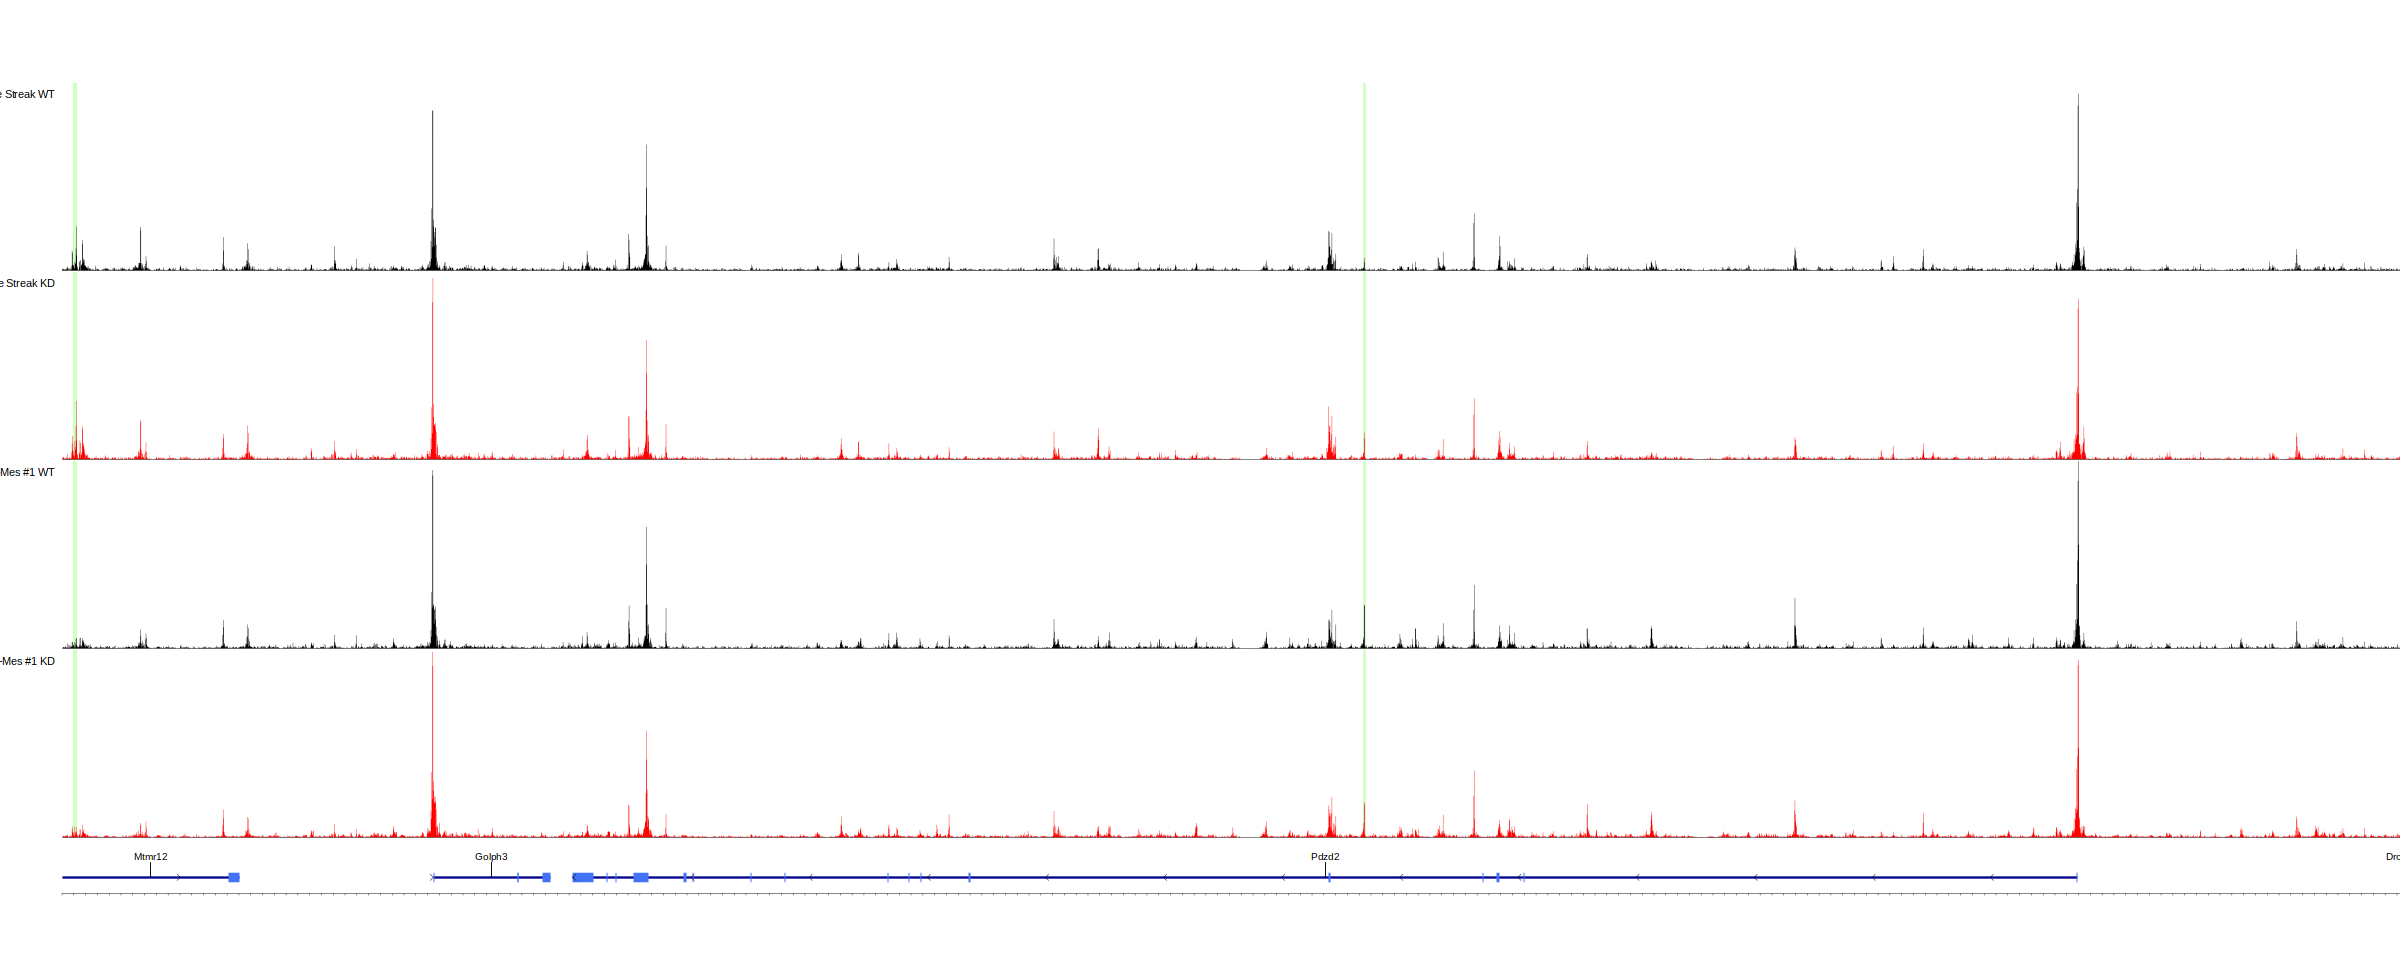

In [235]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Pdzd2', gene_height = 10, bw_width = 500, bw_height = 40)


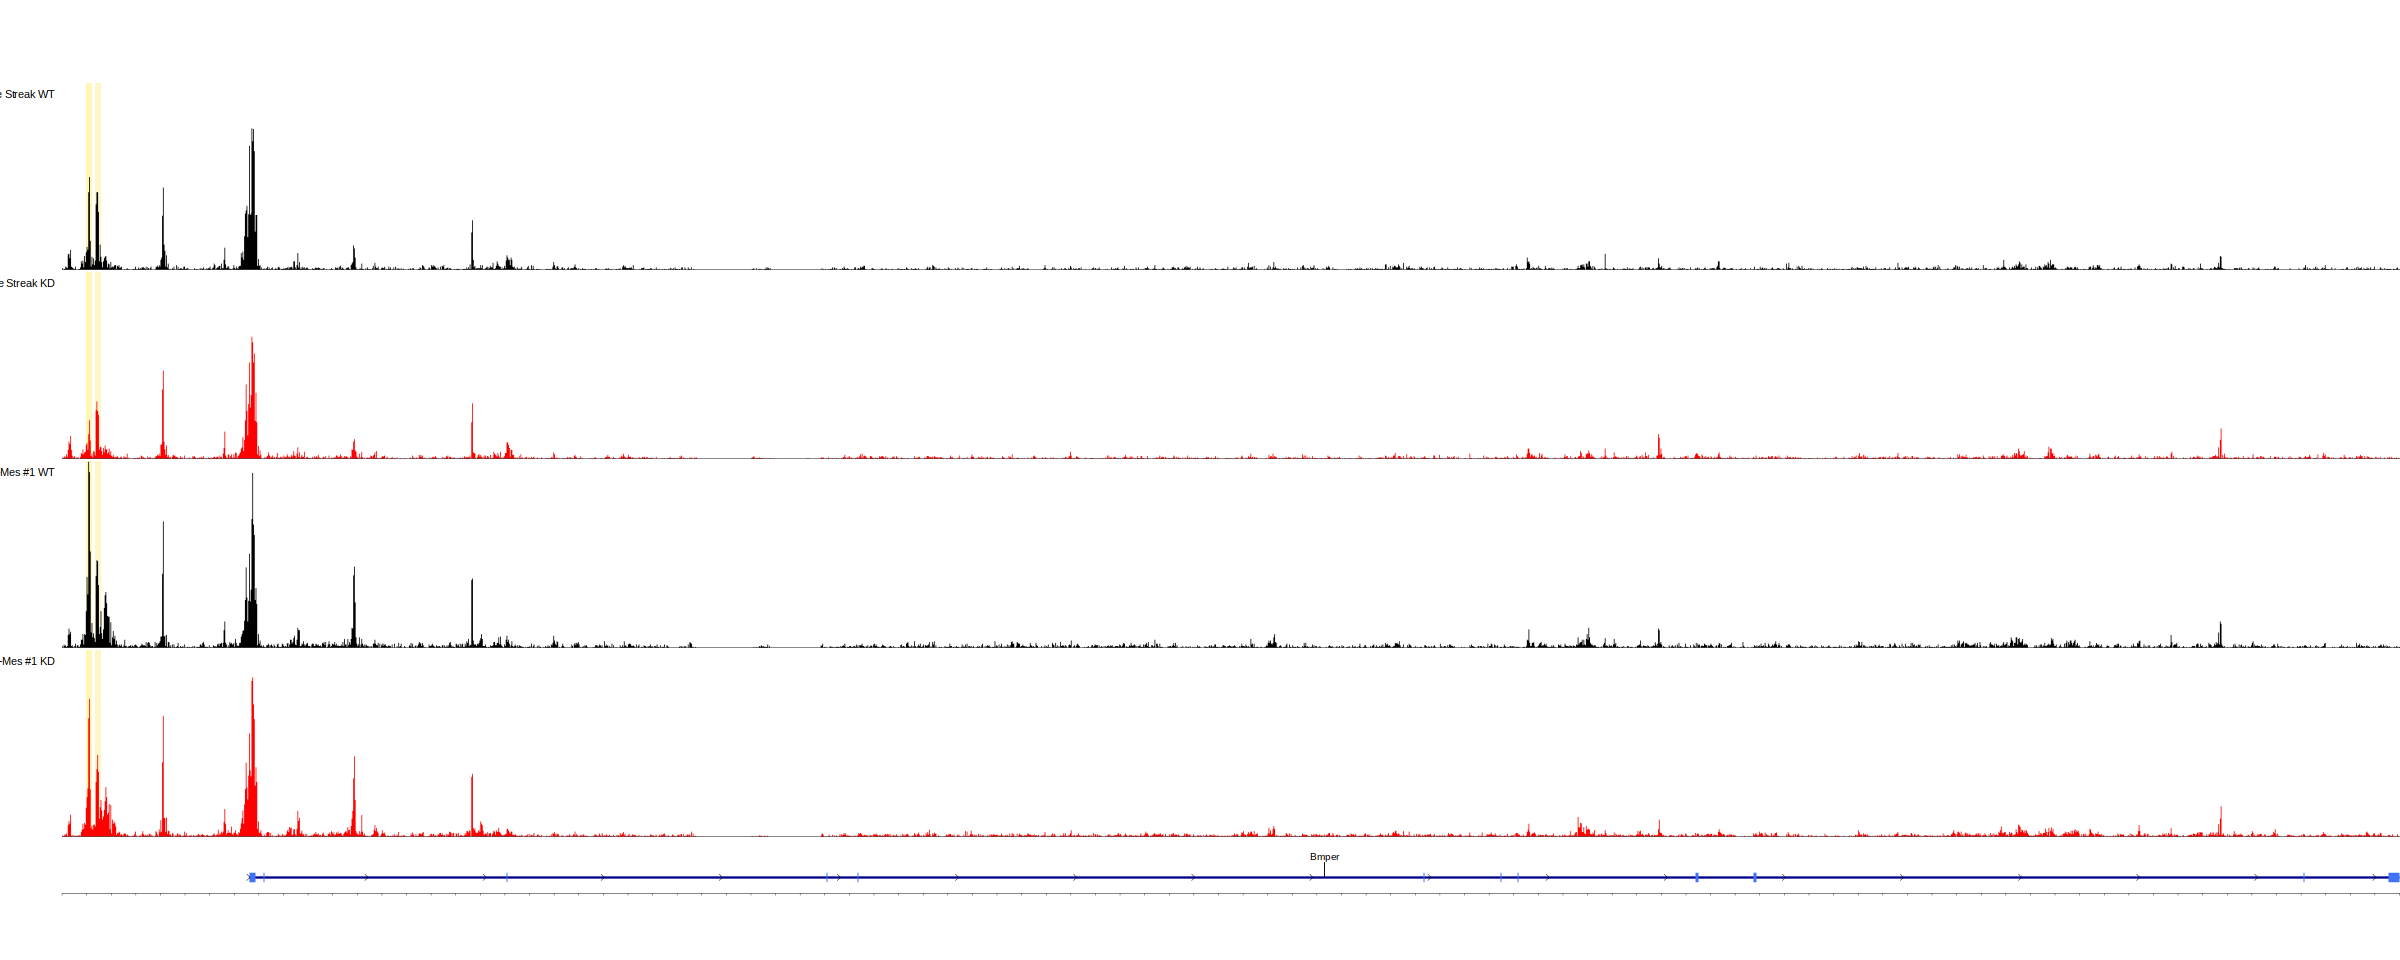

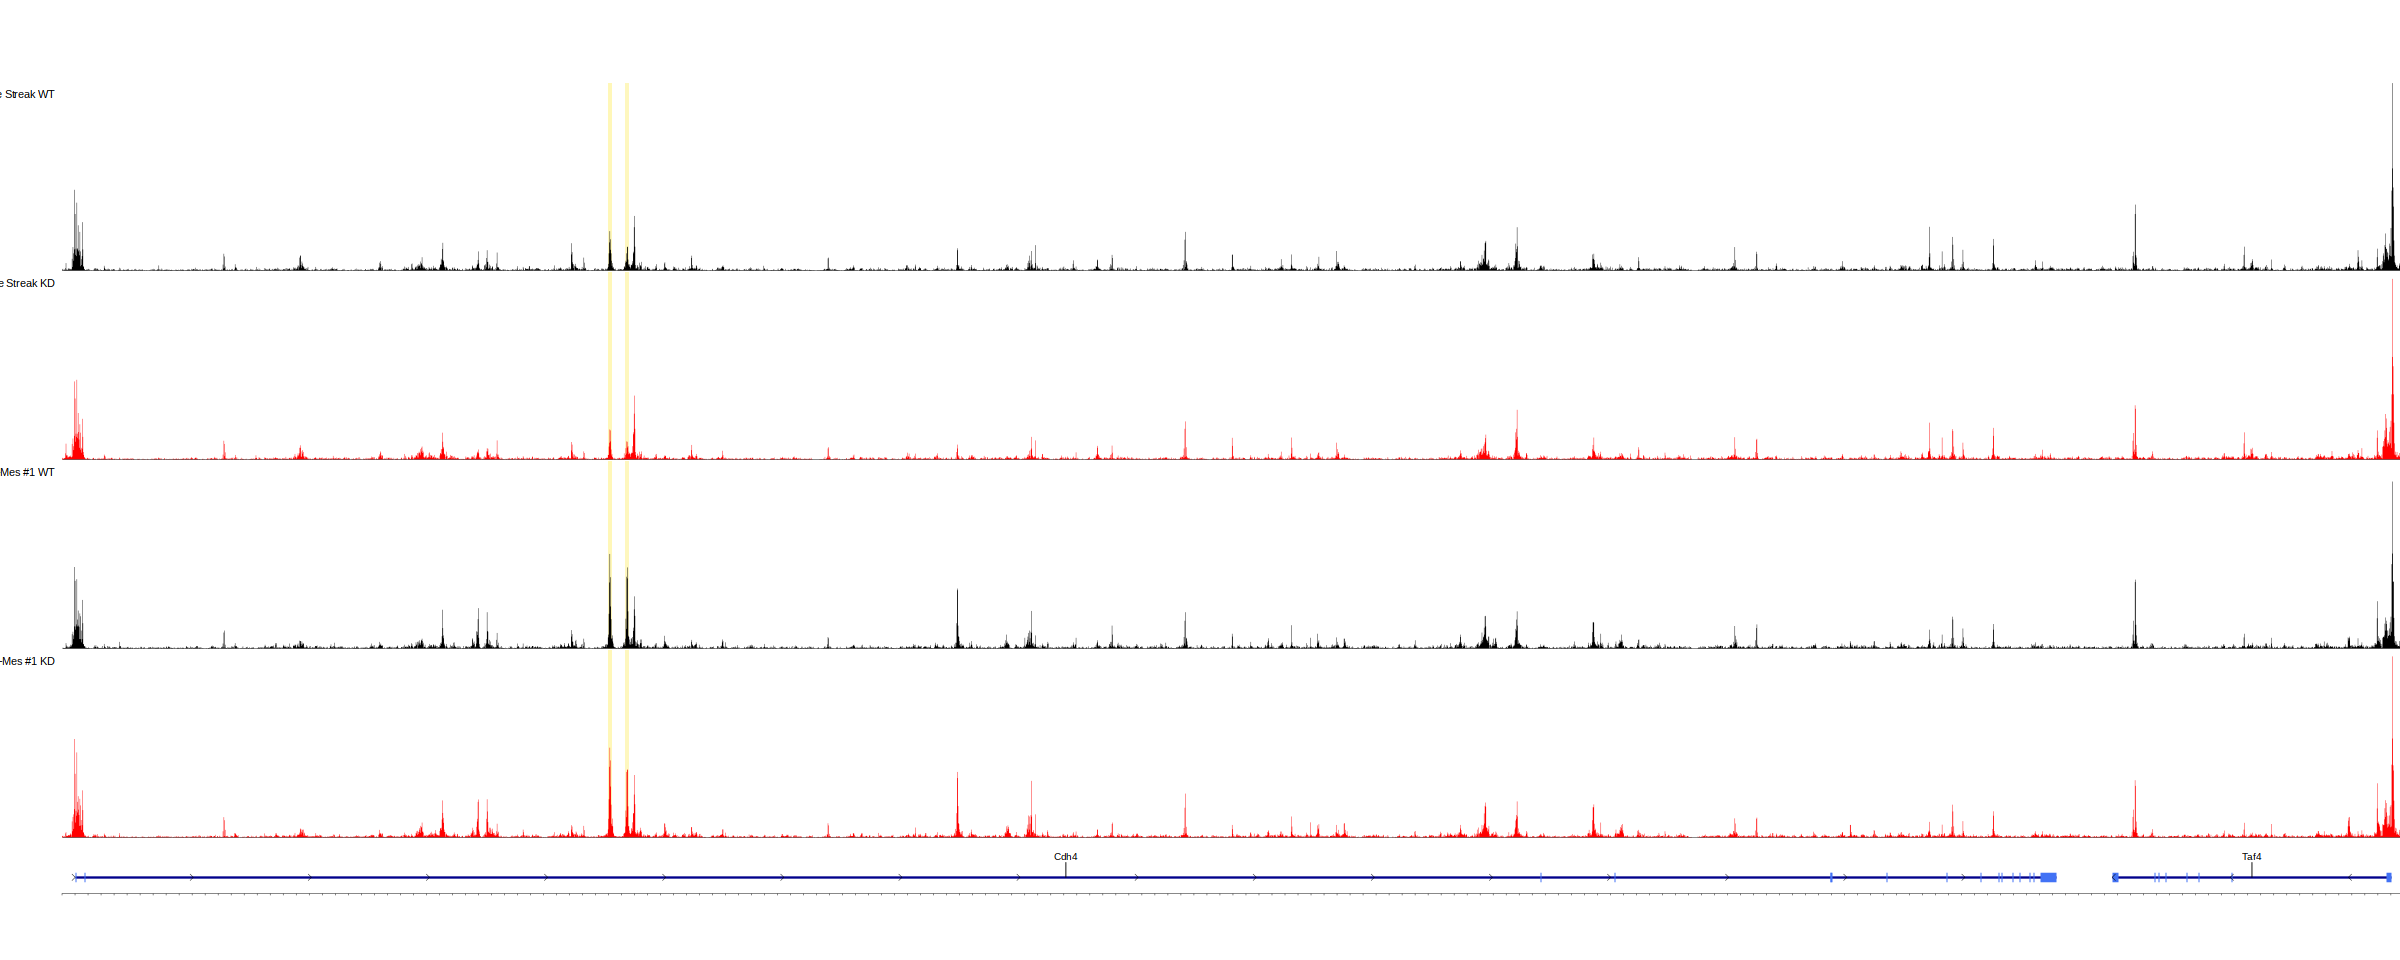

In [236]:
options(repr.plot.height=8, repr.plot.width=20)
plot_region('Bmper', gene_height = 10, bw_width = 500, bw_height = 40)
plot_region('Cdh4', gene_height = 10, bw_width = 500, bw_height = 40)


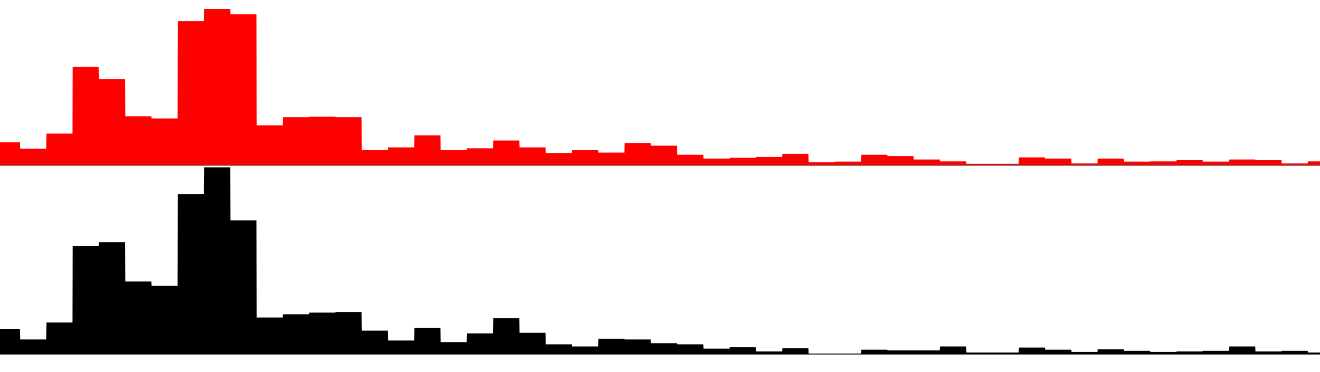

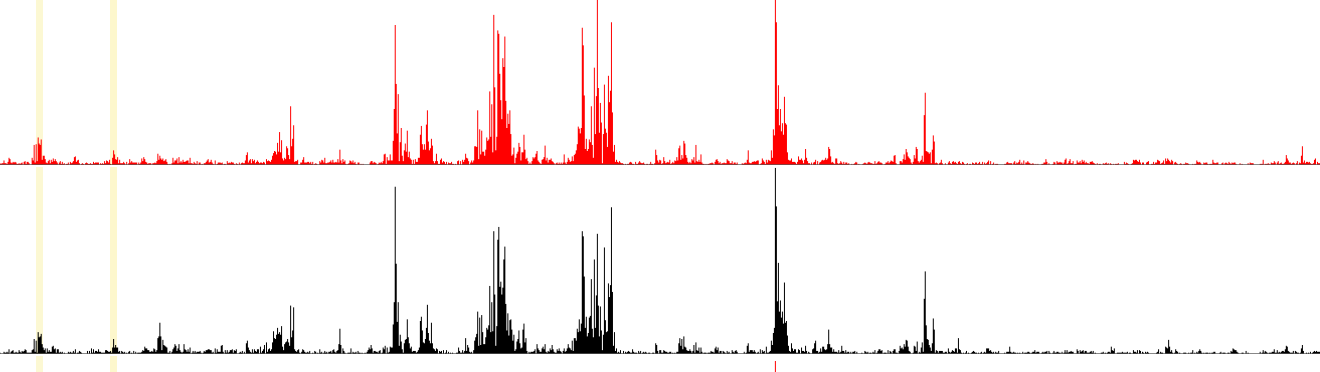

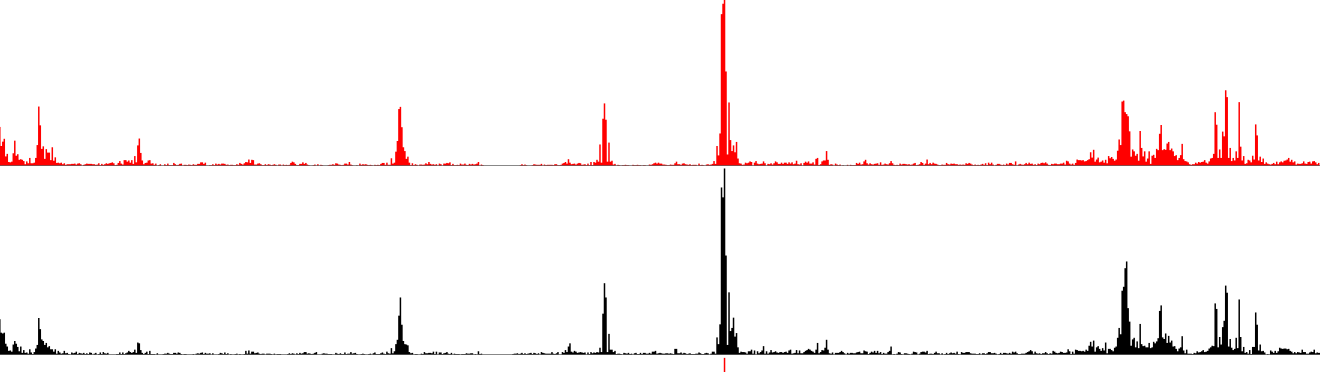

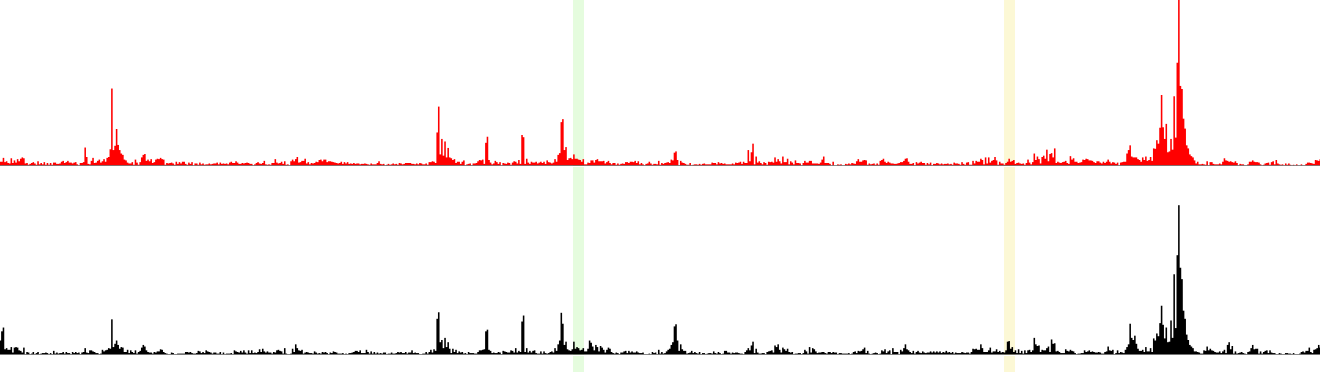

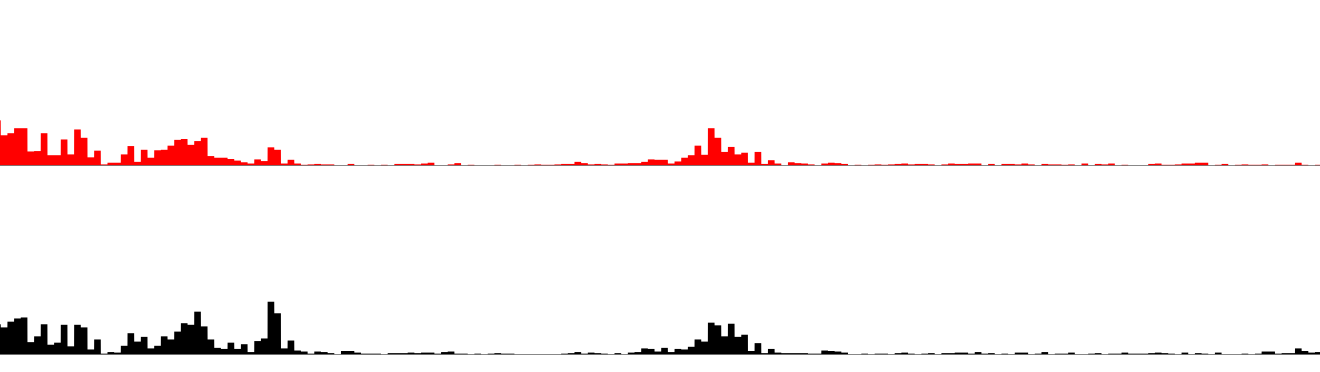

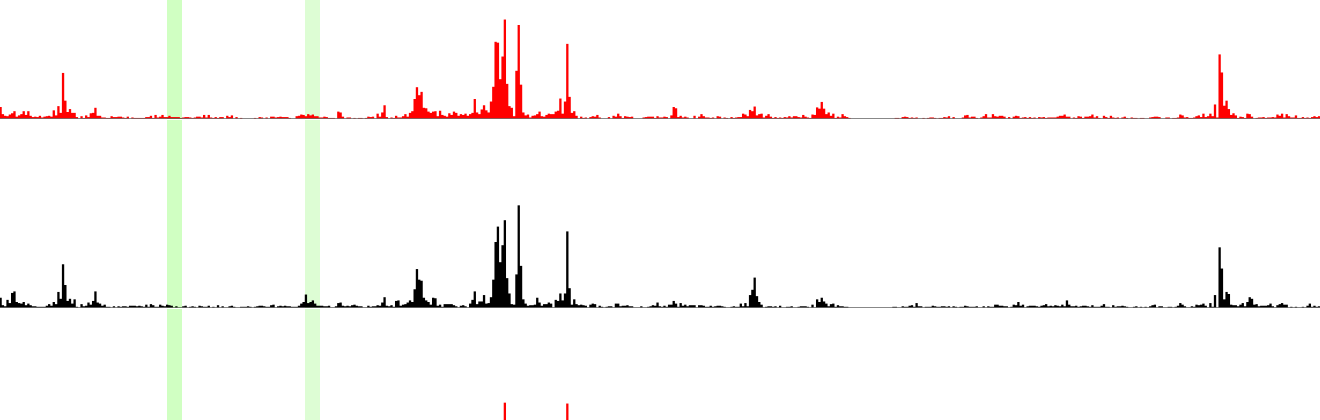

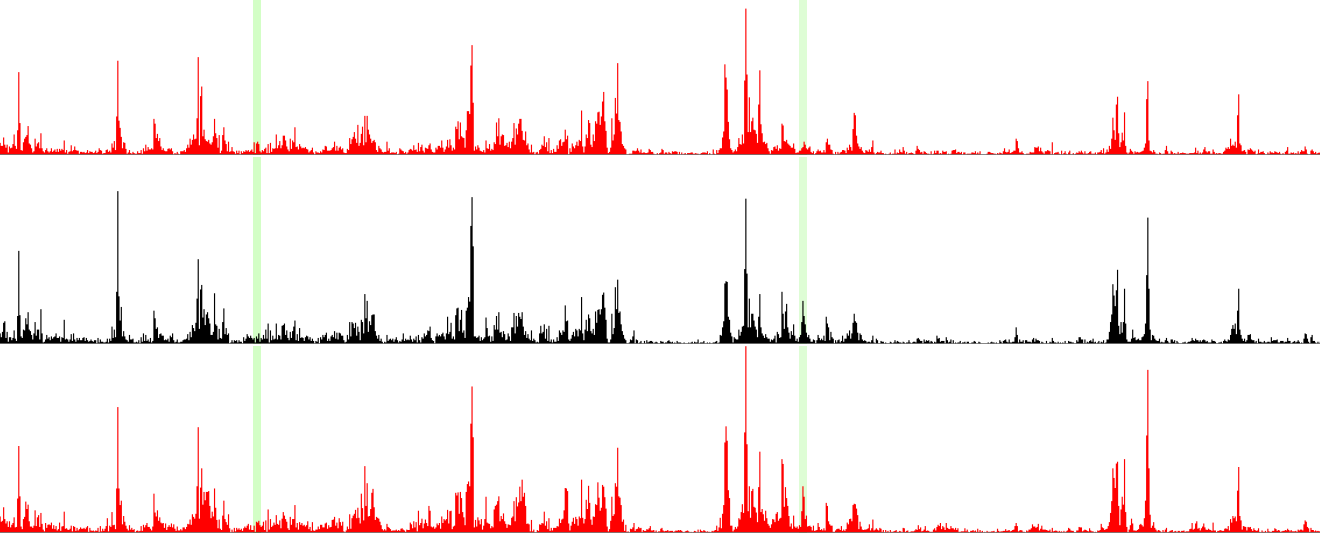

In [110]:
options(repr.plot.height=3.1, repr.plot.width=11)
plot_region('Fzd10', gene_height = 10, bw_width = 500, bw_height = 40)
plot_region('Eomes', gene_height = 10, bw_width = 500, bw_height = 40)
plot_region('Krt8', gene_height = 10, bw_width = 500, bw_height = 40)
plot_region('Nodal', gene_height = 10, bw_width = 500, bw_height = 40)
plot_region('Bmp4', gene_height = 10, bw_width = 500, bw_height = 40)
options(repr.plot.height=3.5, repr.plot.width=11)
plot_region('Tbx3', gene_height = 40, bw_width = 500, bw_height = 40)
options(repr.plot.height=4.5, repr.plot.width=11)
plot_region('Hoxb1', gene_height = 50, bw_width = 500, bw_height = 40)